# TrustOCT — Evaluation & Figures Notebook (cleaned)

Generates every table and figure for the paper/thesis **from already-trained
checkpoints and already-saved predictions**. No training happens in this
notebook.

**What this notebook does, in order:**
1. Environment setup (packages, Drive, Kaggle auth)
2. Build the reusable `trustoct` package
3. Prepare the Kermany OCT2017 dataset (patient-grouped split)
4. Load the precomputed EXP001 / EXP003 predictions
5. Load the EXP003 checkpoint for live inference (needed only for the
   explainability, robustness, and failure-case sections — those need to
   run the model forward, not just read saved predictions)
6. Training curves
7. Ablation metrics table + confusion matrices (**Table 2 / Fig. 2**)
8. Statistical significance — McNemar's test + bootstrap CIs
9. Comparison against published Kermany-OCT literature
10. Calibration — ECE / MCE / Brier + reliability diagrams
11. Explainability & faithfulness — LayerCAM + Deletion/Insertion AOPC
12. Robustness evaluation under perturbations
13. Compute cost analysis (parameters, latency)
14. Failure case gallery
15. Save & back up all artifacts to Drive

> This version removes the diagnostic/debugging cells from the working
> session (file-hunting, permutation checks, dead-end recalibration
> attempts) and keeps only the final, verified path. All the code below is
> your own code from the working notebook — nothing new was invented, it's
> just reordered, deduplicated, and given clear section headers.


## 1. Setup — environment, Drive, Kaggle auth

In [2]:
!pip install -q kagglehub opencv-python-headless
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected — go to Runtime > Change runtime type > GPU before training.")


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# Mount Google Drive (predictions, histories, and checkpoints live here)
import os
import glob
from google.colab import drive

drive.mount('/content/drive')


def find_file(filename):
    """Search the common TrustOCT output locations on Drive for a file."""
    patterns = [
        f'/content/drive/MyDrive/TrustOCT_Outputs/{filename}',
        f'/content/drive/MyDrive/TrustOCT_Outputs/results/{filename}',
        f'/content/drive/MyDrive/TrustOCT_Outputs/checkpoints/{filename}',
        f'/content/drive/MyDrive/TrustOCT_Results/{filename}',
        f'/content/drive/MyDrive/TrustOCT_Results/results/{filename}',
        f'/content/drive/MyDrive/TrustOCT_Results/checkpoints/{filename}',
        f'/content/drive/**/{filename}',
    ]
    for p in patterns:
        matches = glob.glob(p, recursive=True)
        if matches:
            return matches[0]
    return None


Mounted at /content/drive


### 1.1 Kaggle authentication
Needed to pull the Kermany OCT2017 test/train images for the live-inference sections (explainability, robustness, failure gallery). Upload `kaggle.json` **or** set the `KAGGLE_USERNAME` / `KAGGLE_KEY` Colab secrets instead.

In [4]:
import os
# Option A: upload kaggle.json interactively (skip this cell if using Colab secrets instead)
try:
    from google.colab import files
    if not os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")):
        print("Upload your kaggle.json (Kaggle account -> Create New API Token):")
        uploaded = files.upload()
        os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
        for fname in uploaded:
            os.rename(fname, os.path.expanduser("~/.kaggle/kaggle.json"))
        os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
        print("Saved kaggle.json")
    else:
        print("kaggle.json already present.")
except ImportError:
    print("Not running on Colab — set KAGGLE_USERNAME / KAGGLE_KEY env vars manually.")


Upload your kaggle.json (Kaggle account -> Create New API Token):


Saving kaggle.json to kaggle.json
Saved kaggle.json


## 2. Build the `trustoct` package

Writes the reusable modules to disk (mirrors the `trustoct/` package in the
GitHub repo). Kept as one package so the paper's code appendix and the repo
stay in sync with this notebook.
```
trustoct/
  utils.py            # seeding, checkpointing
  modules.py           # CBAM + MSF building blocks
  data.py              # Kermany loading, CLAHE, patient-grouped split
  model.py              # ResNet50 (+MSF, +CBAM) classifier
  train.py              # shared training loop (EXP001/002/003)
  calibration.py         # ECE / MCE / Brier / reliability diagrams
  explainability.py       # LayerCAM + Deletion/Insertion AOPC
  robustness.py            # perturbation battery
  multiseed.py              # multi-seed significance runs
```

In [5]:
import os
os.makedirs('trustoct', exist_ok=True)

In [6]:
%%writefile trustoct/utils.py
"""
trustoct.utils
Reproducibility and misc helpers.
"""
import os
import random
import numpy as np
import torch


def set_seed(seed: int = 42):
    """Fix all relevant seeds. Call this ONCE at the top of every script/notebook cell
    that trains or evaluates a model, so runs are reproducible and defensible in a viva."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total_params": total, "trainable_params": trainable}


def save_checkpoint(model, optimizer, epoch, best_metric, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_metric": best_metric,
    }, path)


def load_checkpoint(model, path, optimizer=None, map_location=None):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt.get("epoch", 0), ckpt.get("best_metric", None)


class AverageMeter:
    """Tracks running average of a metric (loss, acc, etc.) within an epoch."""
    def __init__(self):
        self.reset()

    def reset(self):
        self.sum = 0.0
        self.count = 0

    def update(self, val, n=1):
        self.sum += val * n
        self.count += n

    @property
    def avg(self):
        return self.sum / max(self.count, 1)


Writing trustoct/utils.py


In [7]:
%%writefile trustoct/modules.py
"""
trustoct.modules
Architectural building blocks: CBAM (Convolutional Block Attention Module,
Woo et al. 2018) and MSF (Multi-Scale Feature fusion module).
"""
import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------------------------------------------------------------------------
# CBAM
# ---------------------------------------------------------------------------
class ChannelAttention(nn.Module):
    """Squeezes spatial dims via avg+max pool, learns a shared MLP over both,
    sums, sigmoids -> per-channel weight. Tells the network 'which feature maps
    matter', e.g. layer-thickness channels vs texture channels."""

    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        hidden = max(in_channels // reduction_ratio, 8)
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, in_channels, bias=False),
        )
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

    def forward(self, x):
        b, c, _, _ = x.shape
        avg_out = self.mlp(self.avg_pool(x).view(b, c))
        max_out = self.mlp(self.max_pool(x).view(b, c))
        attn = torch.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * attn


class SpatialAttention(nn.Module):
    """Squeezes channel dim via avg+max pool, convolves the 2-channel map with a
    7x7 kernel, sigmoids -> per-pixel weight. Tells the network 'where to look',
    e.g. the retinal layer boundary region rather than background."""

    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        concat = torch.cat([avg_out, max_out], dim=1)
        attn = torch.sigmoid(self.conv(concat))
        return x * attn


class CBAM(nn.Module):
    """Sequential channel-then-spatial attention, as in the original paper.
    Drop-in module: output has identical shape to input."""

    def __init__(self, in_channels, reduction_ratio=16, spatial_kernel_size=7):
        super().__init__()
        self.channel_attn = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_attn = SpatialAttention(spatial_kernel_size)

    def forward(self, x):
        x = self.channel_attn(x)
        x = self.spatial_attn(x)
        return x


# ---------------------------------------------------------------------------
# MSF - Multi-Scale Feature fusion
# ---------------------------------------------------------------------------
class MSFModule(nn.Module):
    """Fuses feature maps from multiple ResNet stages (e.g. layer2, layer3, layer4)
    at a common spatial resolution and channel width, via 1x1 projection + upsample
    + concatenation + 3x3 fusion conv. Motivation for OCT specifically: pathology
    (fluid pockets in DME, neovascular membranes in CNV, drusen deposits) appears at
    very different physical scales in a B-scan, so a single-resolution feature map
    from only the last ResNet stage can miss small/early-stage lesions.
    """

    def __init__(self, in_channels_list, out_channels=256):
        """in_channels_list: channel counts of the feature maps to fuse, ordered from
        shallow -> deep, e.g. [512, 1024, 2048] for ResNet50 layer2/3/4."""
        super().__init__()
        self.projections = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(c, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ) for c in in_channels_list
        ])
        self.fuse_conv = nn.Sequential(
            nn.Conv2d(out_channels * len(in_channels_list), out_channels,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, feature_maps):
        """feature_maps: list of tensors [B, C_i, H_i, W_i], shallow->deep.
        All are projected to out_channels and upsampled to the shallowest map's
        spatial size before fusion."""
        target_size = feature_maps[0].shape[-2:]
        projected = []
        for feat, proj in zip(feature_maps, self.projections):
            p = proj(feat)
            if p.shape[-2:] != target_size:
                p = F.interpolate(p, size=target_size, mode="bilinear", align_corners=False)
            projected.append(p)
        fused = torch.cat(projected, dim=1)
        return self.fuse_conv(fused)


Writing trustoct/modules.py


In [8]:
%%writefile trustoct/data.py
"""
trustoct.data
Kermany/Mendeley OCT2017 dataset loading for Colab.

Dataset: "Labeled Optical Coherence Tomography (OCT) and Chest X-Ray Images for
Classification" (Kermany et al., 2018) — CNV / DME / DRUSEN / NORMAL, ~84,000 train
images + the original test/val split.

On Colab, the easiest reliable path is Kaggle via kagglehub:
    kaggle dataset: paultimothymooney/kermany2018
"""
import os
import re
import glob
import random
import cv2
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms

CLASSES = ["NORMAL", "CNV", "DME", "DRUSEN"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def download_kermany_dataset(dest_dir="/content/data"):
    """Downloads OCT2017 dataset on Colab using kagglehub.
    Requires kaggle.json uploaded / KAGGLE credentials set, OR kagglehub's
    interactive auth. Run this once per Colab session.
    """
    import kagglehub
    path = kagglehub.dataset_download("paultimothymooney/kermany2018")
    print(f"Dataset downloaded to: {path}")
    return path


def apply_clahe(img_np: np.ndarray, clip_limit=2.0, tile_grid_size=(8, 8)) -> np.ndarray:
    """Contrast-Limited Adaptive Histogram Equalization — standard OCT preprocessing
    step to boost layer contrast before feeding into a network pretrained on natural
    images. Operates on single-channel (grayscale) OCT B-scans."""
    if img_np.ndim == 3:
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    out = clahe.apply(img_np.astype(np.uint8))
    return cv2.cvtColor(out, cv2.COLOR_GRAY2RGB)


class CLAHETransform:
    """torchvision-compatible transform wrapping apply_clahe, operates on PIL Image."""
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, pil_img: Image.Image) -> Image.Image:
        arr = np.array(pil_img.convert("L"))
        out = apply_clahe(arr, self.clip_limit, self.tile_grid_size)
        return Image.fromarray(out)


def build_transforms(image_size=224, train=True, use_clahe=True):
    ops = []
    if use_clahe:
        ops.append(CLAHETransform())
    if train:
        ops += [
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
        ]
    else:
        ops += [transforms.Resize((image_size, image_size))]
    ops += [
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return transforms.Compose(ops)


class OCTDataset(Dataset):
    """Generic ImageFolder-style dataset for CNV/DME/DRUSEN/NORMAL, built from an
    explicit list of file paths so we control the exact train/val/test split
    (important: Kermany's own 'test' folder has only 8 images/class — too small for
    a stable test metric, so we re-split the ~84k 'train' folder ourselves)."""

    def __init__(self, filepaths, labels, transform=None):
        assert len(filepaths) == len(labels)
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        path = self.filepaths[idx]
        label = self.labels[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label, path


def index_kermany_folder(root_train_dir):
    """Scans root_train_dir (or searches recursively) for OCT2017 class folders
    (NORMAL, CNV, DME, DRUSEN) and returns (filepaths, labels)."""
    def scan_dir(d):
        fps, lbs = [], []
        if not os.path.isdir(d):
            return fps, lbs
        subdirs = {entry.upper(): entry for entry in os.listdir(d)}
        for cls in CLASSES:
            if cls in subdirs:
                cls_dir = os.path.join(d, subdirs[cls])
                files = sorted(glob.glob(os.path.join(cls_dir, "*.jpeg")) +
                                glob.glob(os.path.join(cls_dir, "*.jpg")) +
                                glob.glob(os.path.join(cls_dir, "*.png")) +
                                glob.glob(os.path.join(cls_dir, "*.JPEG")) +
                                glob.glob(os.path.join(cls_dir, "*.JPG")) +
                                glob.glob(os.path.join(cls_dir, "*.PNG")))
                fps += files
                lbs += [CLASS_TO_IDX[cls]] * len(files)
        return fps, lbs

    filepaths, labels = scan_dir(root_train_dir)

    # If nothing found directly, search recursively up to 3 levels deep
    if len(filepaths) == 0:
        parent_dir = os.path.dirname(root_train_dir) if root_train_dir else ""
        search_roots = [root_train_dir, parent_dir, os.path.dirname(parent_dir)]
        for root in search_roots:
            if root and os.path.exists(root):
                for dirpath, dirnames, _ in os.walk(root):
                    dirnames_upper = [d.upper() for d in dirnames]
                    if any(c in dirnames_upper for c in CLASSES):
                        fps, lbs = scan_dir(dirpath)
                        if len(fps) > 0:
                            filepaths, labels = fps, lbs
                            break
            if len(filepaths) > 0:
                break

    if len(filepaths) == 0:
        raise RuntimeError(
            f"No OCT images found in '{root_train_dir}'. "
            f"Expected subfolders for classes {CLASSES} containing .jpeg/.png images."
        )

    print(f"Total images found: {len(filepaths)}")
    return filepaths, labels


_PATIENT_ID_PATTERN = re.compile(r"^([A-Za-z]+)-(\d+)-\d+\.\w+$")


def extract_patient_id(filepath):
    """Kermany filenames encode a patient ID: e.g. 'CNV-1016042-1.jpeg' ->
    class=CNV, patient_id=1016042, image_index=1. A single patient contributes
    MULTIPLE B-scans, so splitting by image (not patient) lets the same
    patient's scans leak across train/val/test — inflating reported accuracy,
    since adjacent B-scans from one eye are highly correlated. This extracts
    the patient ID so splitting can be done at the patient level instead.

    Falls back to 'parent_dir/basename' (i.e. treats every image as its own
    'patient', namespaced by its containing folder so fallback IDs can't
    collide across classes) if the filename doesn't match the expected
    pattern — this keeps the pipeline from crashing on an unexpected naming
    scheme, but prints a one-time warning since it means leakage protection
    is NOT actually active for those files.
    """
    basename = os.path.basename(filepath)
    m = _PATIENT_ID_PATTERN.match(basename)
    if m:
        return m.group(2)  # numeric patient ID
    parent_dir = os.path.basename(os.path.dirname(filepath))
    return f"{parent_dir}/{basename}"  # unrecognized pattern -> no real grouping, but namespaced


_warned_ungrouped = False


def patient_grouped_stratified_split(filepaths, labels, val_frac=0.10, test_frac=0.10,
                                      seed=42, max_per_class=None):
    """Stratified split by class AND grouped by patient, so no patient's images
    appear in more than one of train/val/test. This is the split you should
    use for any number you intend to report or publish — a plain per-image
    split (see `stratified_split` below, kept only for quick experimentation)
    silently inflates test accuracy via patient leakage.

    Algorithm per class: group filepaths by patient ID, shuffle the patient
    groups (not the individual images), then greedily assign whole patient
    groups to test -> val -> train until each split's image-count target is
    reached. Patients (not images) are the unit being split, so the final
    image counts will approximate but not exactly hit val_frac/test_frac
    (patients have different numbers of scans).

    max_per_class: caps images per class by keeping whole patient groups
    (never splits a patient's images across the cap boundary) up to
    approximately max_per_class images.
    """
    global _warned_ungrouped
    rng = random.Random(seed)

    # class -> patient_id -> [filepaths]
    by_class_patient = {i: {} for i in range(len(CLASSES))}
    ungrouped_count = 0
    for fp, lb in zip(filepaths, labels):
        pid = extract_patient_id(fp)
        basename = os.path.basename(fp)
        if not _PATIENT_ID_PATTERN.match(basename):
            ungrouped_count += 1
        by_class_patient[lb].setdefault(pid, []).append(fp)

    if ungrouped_count > 0 and not _warned_ungrouped:
        print(f"WARNING: {ungrouped_count} filenames didn't match the expected "
              f"Kermany 'CLASS-patientID-index.ext' pattern and could not be "
              f"grouped by patient — leakage protection is NOT active for them. "
              f"Inspect a few filenames if this number is large.")
        _warned_ungrouped = True

    train_fp, train_lb = [], []
    val_fp, val_lb = [], []
    test_fp, test_lb = [], []
    patient_counts = {"train": 0, "val": 0, "test": 0}

    for cls_idx, patient_dict in by_class_patient.items():
        patient_ids = list(patient_dict.keys())
        rng.shuffle(patient_ids)

        if max_per_class is not None:
            capped_ids, running_total = [], 0
            for pid in patient_ids:
                if running_total >= max_per_class:
                    break
                capped_ids.append(pid)
                running_total += len(patient_dict[pid])
            patient_ids = capped_ids

        total_images = sum(len(patient_dict[pid]) for pid in patient_ids)
        target_val = int(total_images * val_frac)
        target_test = int(total_images * test_frac)

        val_ids, test_ids, train_ids = [], [], []
        running = 0
        for pid in patient_ids:
            n_imgs = len(patient_dict[pid])
            if running < target_test:
                test_ids.append(pid)
            elif running < target_test + target_val:
                val_ids.append(pid)
            else:
                train_ids.append(pid)
            running += n_imgs

        for pid in train_ids:
            train_fp += patient_dict[pid]; train_lb += [cls_idx] * len(patient_dict[pid])
        for pid in val_ids:
            val_fp += patient_dict[pid]; val_lb += [cls_idx] * len(patient_dict[pid])
        for pid in test_ids:
            test_fp += patient_dict[pid]; test_lb += [cls_idx] * len(patient_dict[pid])

        patient_counts["train"] += len(train_ids)
        patient_counts["val"] += len(val_ids)
        patient_counts["test"] += len(test_ids)

    print(f"Split sizes (images) -> train: {len(train_fp)}, val: {len(val_fp)}, test: {len(test_fp)}")
    print(f"Split sizes (patients) -> train: {patient_counts['train']}, "
          f"val: {patient_counts['val']}, test: {patient_counts['test']}")

    assert_no_patient_leakage(train_fp, val_fp, test_fp)

    return (train_fp, train_lb), (val_fp, val_lb), (test_fp, test_lb)


def assert_no_patient_leakage(train_fp, val_fp, test_fp):
    """Hard check: raises if any patient ID appears in more than one split.
    Run this after ANY split you intend to report numbers from — it's cheap
    and it's exactly the check a careful reviewer will ask whether you did."""
    train_ids = {extract_patient_id(fp) for fp in train_fp}
    val_ids = {extract_patient_id(fp) for fp in val_fp}
    test_ids = {extract_patient_id(fp) for fp in test_fp}

    overlap_train_val = train_ids & val_ids
    overlap_train_test = train_ids & test_ids
    overlap_val_test = val_ids & test_ids

    if overlap_train_val or overlap_train_test or overlap_val_test:
        raise ValueError(
            f"Patient leakage detected! "
            f"train/val overlap: {len(overlap_train_val)} patients, "
            f"train/test overlap: {len(overlap_train_test)} patients, "
            f"val/test overlap: {len(overlap_val_test)} patients."
        )
    print("Patient-leakage check passed: no patient appears in more than one split.")


def stratified_split(filepaths, labels, val_frac=0.10, test_frac=0.10, seed=42,
                      max_per_class=None):
    """DEPRECATED for reporting numbers — splits by IMAGE, not patient, so the
    same patient's B-scans can land in both train and test (leakage inflates
    test accuracy). Kept only for fast, throwaway smoke-testing of the
    pipeline itself. Use `patient_grouped_stratified_split` for anything you
    intend to put in a table or a paper.
    """
    rng = random.Random(seed)
    by_class = {i: [] for i in range(len(CLASSES))}
    for fp, lb in zip(filepaths, labels):
        by_class[lb].append(fp)

    train_fp, train_lb = [], []
    val_fp, val_lb = [], []
    test_fp, test_lb = [], []

    for cls_idx, files in by_class.items():
        rng.shuffle(files)
        if max_per_class is not None:
            files = files[:max_per_class]
        n = len(files)
        n_val = int(n * val_frac)
        n_test = int(n * test_frac)
        val_files = files[:n_val]
        test_files = files[n_val:n_val + n_test]
        train_files = files[n_val + n_test:]

        train_fp += train_files; train_lb += [cls_idx] * len(train_files)
        val_fp += val_files;     val_lb += [cls_idx] * len(val_files)
        test_fp += test_files;   test_lb += [cls_idx] * len(test_files)

    print(f"Split sizes -> train: {len(train_fp)}, val: {len(val_fp)}, test: {len(test_fp)}")
    print("NOTE: this is an image-level split (not patient-grouped) — do not "
          "report numbers from this split in a paper/thesis. Use "
          "patient_grouped_stratified_split instead.")
    return (train_fp, train_lb), (val_fp, val_lb), (test_fp, test_lb)


Writing trustoct/data.py


In [9]:
%%writefile trustoct/model.py
"""
trustoct.model
ResNet50 (+ optional MSF, + optional CBAM) classifier for OCT.

IMPORTANT NAMING NOTE (read this before writing the paper):
TrustOCT is the FRAMEWORK — the evaluation methodology spanning metrics,
calibration, explainability faithfulness, and robustness (see trustoct/__init__.py).
The class below, `ResNetMSFCBAM`, is just ONE reference model used to
demonstrate that framework. Keeping these conceptually separate is what makes
the contribution "a framework" rather than "a CNN with a fancy name" — say so
explicitly in the paper's contribution statement.

Three experiment configs share this single class, controlled by two flags,
so the ablation (EXP001 -> EXP002 -> EXP003) is a true controlled comparison
(same backbone, same head, same training recipe):
    EXP001: use_msf=False, use_cbam=False   (plain ResNet50 baseline)
    EXP003: use_msf=True,  use_cbam=True    (+MSF+CBAM)  <- the reference model

MSF here is used as a fusion mechanism to demonstrate the framework, not
presented as a novel architectural contribution in its own right — the paper's
novelty claim should rest on the evaluation methodology, not the backbone.
"""
import torch
import torch.nn as nn
import torchvision.models as tv_models

from trustoct.modules import CBAM, MSFModule


class ResNetMSFCBAM(nn.Module):
    def __init__(self, num_classes=4, use_msf=True, use_cbam=True,
                 pretrained=True, msf_out_channels=256, cbam_reduction=16):
        super().__init__()
        self.use_msf = use_msf
        self.use_cbam = use_cbam

        weights = tv_models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        backbone = tv_models.resnet50(weights=weights)

        # Split backbone into stages so we can tap intermediate feature maps.
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1   # 256 ch
        self.layer2 = backbone.layer2   # 512 ch
        self.layer3 = backbone.layer3   # 1024 ch
        self.layer4 = backbone.layer4   # 2048 ch

        if self.use_msf:
            self.msf = MSFModule(in_channels_list=[512, 1024, 2048], out_channels=msf_out_channels)
            head_in_channels = msf_out_channels
        else:
            head_in_channels = 2048

        if self.use_cbam:
            self.cbam = CBAM(head_in_channels, reduction_ratio=cbam_reduction)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(head_in_channels, num_classes)

        # Keep a handle to the last conv feature map for Grad-CAM/LayerCAM hooks.
        self._last_features = None

    def forward(self, x, return_features=False):
        x = self.stem(x)
        c1 = self.layer1(x)
        c2 = self.layer2(c1)
        c3 = self.layer3(c2)
        c4 = self.layer4(c3)

        if self.use_msf:
            feat = self.msf([c2, c3, c4])
        else:
            feat = c4

        if self.use_cbam:
            feat = self.cbam(feat)

        self._last_features = feat  # used by explainability hooks

        pooled = self.gap(feat).flatten(1)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        if return_features:
            return logits, feat
        return logits

    def get_target_layer(self):
        """Returns the module whose output activations/gradients LayerCAM should use.
        This is the final fused+attended feature map -> most semantically meaningful
        for a class-discriminative heatmap."""
        if self.use_cbam:
            return self.cbam
        if self.use_msf:
            return self.msf
        return self.layer4


EXPERIMENTS = {
    "EXP001_baseline_resnet50": dict(use_msf=False, use_cbam=False),
    "EXP003_resnet50_msf_cbam": dict(use_msf=True, use_cbam=True),
}


def build_model(exp_name, num_classes=4, pretrained=True):
    """Generic factory, kept for programmatic/looped use (e.g. multiseed.py)."""
    assert exp_name in EXPERIMENTS, f"Unknown exp_name. Choose from {list(EXPERIMENTS.keys())}"
    cfg = EXPERIMENTS[exp_name]
    return ResNetMSFCBAM(num_classes=num_classes, pretrained=pretrained, **cfg)


# --- Explicit named factories -------------------------------------------------
# Reviewer feedback: prefer explicit constructors over scattering boolean flags
# through calling code. Use these directly in notebook/paper code listings;
# build_model() above stays available for anywhere you need to loop over
# EXPERIMENTS programmatically (e.g. the multiseed runner).

def build_resnet50(num_classes=4, pretrained=True):
    """EXP001: plain ResNet50 baseline, no MSF, no CBAM."""
    return ResNetMSFCBAM(num_classes=num_classes, use_msf=False, use_cbam=False, pretrained=pretrained)


def build_resnet50_msf_cbam(num_classes=4, pretrained=True):
    """EXP003: ResNet50 + MSF + CBAM — the TrustOCT reference model."""
    return ResNetMSFCBAM(num_classes=num_classes, use_msf=True, use_cbam=True, pretrained=pretrained)


# Backward-compatible alias — remove before final submission once all
# notebook cells / saved-script references are confirmed migrated to the new name.
TrustOCTNet = ResNetMSFCBAM


Writing trustoct/model.py


In [10]:
%%writefile trustoct/train.py
"""
trustoct.train
Training loop shared by all three experiments (EXP001/002/003), so the only
difference between runs is the model architecture — everything else (optimizer,
schedule, augmentation, loss, seed) is held fixed for a fair ablation.
"""
import time
import copy
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from trustoct.utils import AverageMeter, save_checkpoint, get_device


def compute_class_weights(labels, num_classes):
    """Inverse-frequency class weights, used in the loss to counter Kermany's
    class imbalance (NORMAL is undersampled relative to CNV/DME/DRUSEN)."""
    counts = torch.zeros(num_classes)
    for lb in labels:
        counts[lb] += 1
    weights = counts.sum() / (num_classes * counts.clamp(min=1))
    return weights


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    loss_meter, acc_meter = AverageMeter(), AverageMeter()
    for images, labels, _ in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        acc = (preds == labels).float().mean().item()
        loss_meter.update(loss.item(), images.size(0))
        acc_meter.update(acc, images.size(0))
    return loss_meter.avg, acc_meter.avg


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    loss_meter, acc_meter = AverageMeter(), AverageMeter()
    for images, labels, _ in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)
        acc = (preds == labels).float().mean().item()
        loss_meter.update(loss.item(), images.size(0))
        acc_meter.update(acc, images.size(0))
    return loss_meter.avg, acc_meter.avg


def fit(model, train_ds, val_ds, exp_name, epochs=25, batch_size=32, lr=1e-4,
        weight_decay=1e-4, num_workers=2, patience=5, ckpt_dir="/content/checkpoints",
        class_weights=None, overfit_gap_threshold=0.15, overfit_patience=3,
        min_epochs=5, verbose=True):
    """Full training run with TWO independent early-stopping triggers, plus
    best-checkpoint saving. Returns the trained model (best weights loaded) and
    a history dict (including a per-epoch overfit_gap) for the loss/accuracy
    curves you'll want in the thesis.

    Early-stop triggers (either one alone can end training):

    1. **Val-loss plateau** (`patience`): stops if val_loss hasn't improved for
       `patience` consecutive epochs. Catches the case where the model has
       simply stopped getting better.

    2. **Overfitting gap** (`overfit_gap_threshold`, `overfit_patience`): stops
       if `train_acc - val_acc` exceeds `overfit_gap_threshold` for
       `overfit_patience` consecutive epochs. This catches the case a pure
       val-loss patience check MISSES — val_loss can still be (slowly)
       improving even while the train/val gap widens, especially with a
       pretrained backbone that memorizes quickly. `min_epochs` guards against
       triggering this before the model has had a chance to warm up.

    In both cases the model reverts to the BEST checkpoint by val_loss (not the
    epoch training stopped at), so an overfitting-triggered stop still returns
    the best generalizing weights seen so far, not an already-overfit model.
    """
    device = get_device()
    model = model.to(device)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                               num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device) if class_weights is not None else None)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    epochs_no_improve = 0
    overfit_streak = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "overfit_gap": []}
    stop_reason = "completed all epochs"

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        gap = tr_acc - val_acc  # positive & growing -> overfitting signature

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["overfit_gap"].append(gap)

        elapsed = time.time() - t0
        if verbose:
            flag = "  <- overfit gap high" if gap > overfit_gap_threshold else ""
            print(f"[{exp_name}] epoch {epoch:02d}/{epochs} | "
                  f"train_loss {tr_loss:.4f} acc {tr_acc:.4f} | "
                  f"val_loss {val_loss:.4f} acc {val_acc:.4f} | "
                  f"gap {gap:+.4f} | {elapsed:.1f}s{flag}")

        # --- checkpoint on best val_loss ---
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_no_improve = 0
            save_checkpoint(model, optimizer, epoch, best_val_loss,
                             f"{ckpt_dir}/{exp_name}_best.pt")
        else:
            epochs_no_improve += 1

        # --- overfitting-gap trigger ---
        if epoch >= min_epochs and gap > overfit_gap_threshold:
            overfit_streak += 1
        else:
            overfit_streak = 0

        # --- check both stopping conditions ---
        if epochs_no_improve >= patience:
            stop_reason = (f"val_loss plateaued for {patience} epochs "
                            f"(best val_loss={best_val_loss:.4f} at epoch {best_epoch})")
            break
        if overfit_streak >= overfit_patience:
            stop_reason = (f"train/val accuracy gap exceeded {overfit_gap_threshold:.2f} "
                            f"for {overfit_patience} consecutive epochs "
                            f"(gap={gap:.3f} at epoch {epoch}) — reverting to best "
                            f"checkpoint from epoch {best_epoch}")
            break

    if verbose:
        print(f"[{exp_name}] Stopped: {stop_reason}")
        print(f"[{exp_name}] Restoring best weights from epoch {best_epoch} "
              f"(val_loss={best_val_loss:.4f}).")

    model.load_state_dict(best_state)
    history["stop_reason"] = stop_reason
    history["best_epoch"] = best_epoch
    return model, history


Writing trustoct/train.py


In [11]:
%%writefile trustoct/calibration.py
"""
trustoct.calibration
Phase 3 core differentiator, part A: is the model's confidence trustworthy?
Most OCT papers report accuracy only; a model can be accurate yet badly
overconfident, which matters clinically (a 99%-confident wrong prediction is more
dangerous than a 55%-confident wrong one). We quantify this with:
  - Expected Calibration Error (ECE)
  - Brier score (multiclass)
  - Reliability diagrams (plotted, for EXP001 vs EXP003)
"""
import numpy as np
import matplotlib.pyplot as plt


def expected_calibration_error(y_true, y_prob, n_bins=15):
    """ECE = sum over bins of (|bin|/N) * |accuracy(bin) - confidence(bin)|,
    using max predicted probability (top-1 confidence) per sample, standard
    definition from Guo et al. 2017 ('On Calibration of Modern Neural Networks')."""
    confidences = y_prob.max(axis=1)
    predictions = y_prob.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_stats = []
    for i in range(n_bins):
        lo, hi = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (confidences > lo) & (confidences <= hi) if i > 0 else \
                 (confidences >= lo) & (confidences <= hi)
        prop_in_bin = in_bin.mean()
        if prop_in_bin > 0:
            acc_in_bin = accuracies[in_bin].mean()
            conf_in_bin = confidences[in_bin].mean()
            ece += np.abs(acc_in_bin - conf_in_bin) * prop_in_bin
            bin_stats.append((lo, hi, acc_in_bin, conf_in_bin, prop_in_bin))
        else:
            bin_stats.append((lo, hi, np.nan, np.nan, 0.0))
    return float(ece), bin_stats


def brier_score_multiclass(y_true, y_prob, num_classes):
    """Multiclass Brier score: mean squared error between predicted probability
    vector and one-hot true label, averaged over samples. Lower is better; a
    perfectly calibrated + accurate model scores 0."""
    y_onehot = np.eye(num_classes)[y_true]
    return float(np.mean(np.sum((y_prob - y_onehot) ** 2, axis=1)))


def plot_reliability_diagram(bin_stats_dict, title="Reliability Diagram", save_path=None):
    """bin_stats_dict: {exp_name: bin_stats} where bin_stats comes from
    expected_calibration_error(). Plots one line per experiment against the
    perfect-calibration diagonal — this is the figure that visually backs up
    your ECE numbers in the paper."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")

    for exp_name, bin_stats in bin_stats_dict.items():
        confs = [b[3] for b in bin_stats if not np.isnan(b[3])]
        accs = [b[2] for b in bin_stats if not np.isnan(b[2])]
        ax.plot(confs, accs, marker="o", label=exp_name)

    ax.set_xlabel("Mean predicted confidence")
    ax.set_ylabel("Empirical accuracy")
    ax.set_title(title)
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200)
    return fig


def calibration_report(y_true, y_prob, num_classes, n_bins=15):
    """
    Beyond ECE/Brier, also reports average confidence and average correctness
    (accuracy) as plain scalars — simple numbers, but they let a reader
    interpret the DIRECTION of miscalibration at a glance: if avg_confidence >
    avg_accuracy the model is overconfident (the more clinically concerning
    direction); if avg_confidence < avg_accuracy it's underconfident.
    """
    ece, bin_stats = expected_calibration_error(y_true, y_prob, n_bins)
    brier = brier_score_multiclass(y_true, y_prob, num_classes)

    confidences = y_prob.max(axis=1)
    predictions = y_prob.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)
    avg_confidence = float(confidences.mean())
    avg_accuracy = float(accuracies.mean())

    return {
        "ece": ece,
        "brier_score": brier,
        "avg_confidence": avg_confidence,
        "avg_accuracy": avg_accuracy,
        "confidence_minus_accuracy": avg_confidence - avg_accuracy,  # >0 = overconfident
    }, bin_stats


Writing trustoct/calibration.py


In [12]:
%%writefile trustoct/explainability.py
"""
trustoct.explainability
Phase 3 core differentiator, part B: are the model's explanations faithful, not
just pretty? Most OCT papers stop at a qualitative Grad-CAM picture. We add:
  - LayerCAM (Jiang et al. 2021) — finer-grained than Grad-CAM since it uses
    positive per-pixel gradient*activation rather than a single global-average
    weight per channel, which matters for small OCT lesions (e.g. early drusen).
  - Deletion/Insertion AOPC (Area Over Perturbation Curve, Samek et al. 2017) —
    a quantitative faithfulness score.
"""

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm


class LayerCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, image_tensor, class_idx=None):
        self.model.eval()
        image_tensor = image_tensor.clone().requires_grad_(True)
        logits = self.model(image_tensor)
        probs = torch.softmax(logits, dim=1)

        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())

        self.model.zero_grad()
        score = logits[0, class_idx]
        score.backward()

        weights = F.relu(self.gradients)
        weighted_activations = weights * self.activations
        cam = F.relu(weighted_activations.sum(dim=1, keepdim=True))

        cam = F.interpolate(cam, size=image_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, class_idx, float(probs[0, class_idx].item())


def overlay_cam_on_image(image_np, cam, alpha=0.6, threshold=0.15):
    """Focused focal overlay: suppresses low-level background noise and highlights
    pathology/lesion areas in vibrant red/yellow/green over the sharp grayscale B-scan."""
    cam_focused = np.clip((cam - threshold) / (1.0 - threshold + 1e-8), 0, 1)
    cam_focused = np.power(cam_focused, 1.5)

    heatmap = cm.get_cmap("jet")(cam_focused)[:, :, :3]
    weight = alpha * cam_focused[..., None]
    overlay = image_np * (1.0 - weight) + heatmap * weight
    return np.clip(overlay, 0, 1)


@torch.no_grad()
def _predict_prob(model, image_tensor, class_idx):
    logits = model(image_tensor)
    prob = torch.softmax(logits, dim=1)[0, class_idx].item()
    return prob


def deletion_insertion_curves(model, image_tensor, cam, class_idx, device,
                                num_steps=20, baseline_value=0.0):
    model.eval()
    img = image_tensor.clone().to(device)
    C, H, W = img.shape[1], img.shape[2], img.shape[3]

    flat_order = np.argsort(-cam.flatten())
    total_pixels = H * W
    step_size = max(total_pixels // num_steps, 1)

    # --- Deletion ---
    del_img = img.clone()
    deletion_scores = [_predict_prob(model, del_img, class_idx)]
    mask_flat = np.ones(total_pixels, dtype=bool)
    for step in range(1, num_steps + 1):
        idx_to_remove = flat_order[(step - 1) * step_size: step * step_size]
        mask_flat[idx_to_remove] = False
        mask_2d = torch.tensor(mask_flat.reshape(H, W), device=device, dtype=torch.float32)
        del_img = image_tensor.to(device) * mask_2d + baseline_value * (1 - mask_2d)
        deletion_scores.append(_predict_prob(model, del_img, class_idx))

    # --- Insertion ---
    ins_img_base = torch.full_like(img, baseline_value)
    insertion_scores = [_predict_prob(model, ins_img_base, class_idx)]
    mask_flat = np.zeros(total_pixels, dtype=bool)
    for step in range(1, num_steps + 1):
        idx_to_add = flat_order[(step - 1) * step_size: step * step_size]
        mask_flat[idx_to_add] = True
        mask_2d = torch.tensor(mask_flat.reshape(H, W), device=device, dtype=torch.float32)
        ins_img = image_tensor.to(device) * mask_2d + baseline_value * (1 - mask_2d)
        insertion_scores.append(_predict_prob(model, ins_img, class_idx))

    _trapz = getattr(np, "trapezoid", None) or np.trapz
    x_axis = np.linspace(0, 1, num_steps + 1)
    del_aopc = float(_trapz(deletion_scores, x_axis))
    ins_aopc = float(_trapz(insertion_scores, x_axis))

    return deletion_scores, insertion_scores, del_aopc, ins_aopc


def faithfulness_report(model, cam_engine, loader, device, num_samples=50, num_steps=20):
    del_aopcs, ins_aopcs = [], []
    seen = 0
    for batch in loader:
        images = batch[0]
        for i in range(images.size(0)):
            if seen >= num_samples:
                break
            img = images[i:i + 1].to(device)
            cam, pred_idx, _ = cam_engine.generate(img)
            _, _, del_aopc, ins_aopc = deletion_insertion_curves(
                model, img, cam, pred_idx, device, num_steps=num_steps)
            del_aopcs.append(del_aopc)
            ins_aopcs.append(ins_aopc)
            seen += 1
        if seen >= num_samples:
            break
    return {
        "mean_deletion_aopc": float(np.mean(del_aopcs)) if len(del_aopcs) > 0 else float("nan"),
        "mean_insertion_aopc": float(np.mean(ins_aopcs)) if len(ins_aopcs) > 0 else float("nan"),
        "n_samples": seen,
    }


def plot_cam_grid(images_np, cams, titles, save_path=None):
    """Paper-quality qualitative grid: Original B-Scan | Focused LayerCAM | Focused Overlay."""
    n = len(images_np)
    if n == 0:
        print("Warning: plot_cam_grid received 0 images. Skipping plot creation.")
        fig, ax = plt.subplots(figsize=(4, 2))
        ax.text(0.5, 0.5, "No samples available", ha='center', va='center', fontsize=12)
        ax.axis("off")
        if save_path:
            fig.savefig(save_path, dpi=200)
        return fig
    fig, axes = plt.subplots(n, 3, figsize=(10, 3.2 * n))
    if n == 1:
        axes = axes[None, :]
    for i in range(n):
        axes[i, 0].imshow(images_np[i])
        axes[i, 0].set_title(f"{titles[i]}\nOriginal B-Scan", fontsize=10)
        axes[i, 0].axis("off")

        cam_focused = np.clip((cams[i] - 0.15) / 0.85, 0, 1)
        cam_focused = np.power(cam_focused, 1.5)
        axes[i, 1].imshow(cam_focused, cmap="jet")
        axes[i, 1].set_title("LayerCAM Heatmap", fontsize=10)
        axes[i, 1].axis("off")

        overlay = overlay_cam_on_image(images_np[i], cams[i], alpha=0.6, threshold=0.15)
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("LayerCAM Overlay", fontsize=10)
        axes[i, 2].axis("off")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200)
    return fig

Writing trustoct/explainability.py


In [13]:
%%writefile trustoct/robustness.py
"""
trustoct.robustness
Phase 4 (supporting, keep lean): does accuracy hold up under realistic OCT
acquisition noise? 4 perturbation types x a few severities, one summary table.
"""
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score


def add_gaussian_noise(img_tensor, severity):
    sigma = [0.02, 0.05, 0.08, 0.12][severity - 1]
    noise = torch.randn_like(img_tensor) * sigma
    return torch.clamp(img_tensor + noise, -3, 3)  # normalized-space clamp


def add_gaussian_blur(img_tensor, severity):
    ksize = [3, 5, 7, 9][severity - 1]
    sigma = ksize / 6.0
    channels = img_tensor.shape[1]
    coords = torch.arange(ksize, dtype=torch.float32) - ksize // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = (g / g.sum()).to(img_tensor.device)
    kernel_1d = g.view(1, 1, 1, ksize)
    kernel_1d_t = g.view(1, 1, ksize, 1)
    kernel_1d = kernel_1d.repeat(channels, 1, 1, 1)
    kernel_1d_t = kernel_1d_t.repeat(channels, 1, 1, 1)
    pad = ksize // 2
    x = F.conv2d(img_tensor, kernel_1d, padding=(0, pad), groups=channels)
    x = F.conv2d(x, kernel_1d_t, padding=(pad, 0), groups=channels)
    return x


def adjust_brightness(img_tensor, severity, mean, std):
    """Adjust brightness in *unnormalized* pixel space then re-normalize, so the
    perturbation magnitude is physically meaningful (fraction of pixel range)."""
    delta = [0.06, 0.12, 0.20, 0.30][severity - 1]
    mean_t = torch.tensor(mean, device=img_tensor.device).view(1, -1, 1, 1)
    std_t = torch.tensor(std, device=img_tensor.device).view(1, -1, 1, 1)
    pixel = img_tensor * std_t + mean_t
    pixel = torch.clamp(pixel + delta, 0, 1)
    return (pixel - mean_t) / std_t


def adjust_contrast(img_tensor, severity, mean, std):
    factor = [0.9, 0.75, 0.6, 0.45][severity - 1]
    mean_t = torch.tensor(mean, device=img_tensor.device).view(1, -1, 1, 1)
    std_t = torch.tensor(std, device=img_tensor.device).view(1, -1, 1, 1)
    pixel = img_tensor * std_t + mean_t
    gray_mean = pixel.mean(dim=[2, 3], keepdim=True)
    pixel = torch.clamp((pixel - gray_mean) * factor + gray_mean, 0, 1)
    return (pixel - mean_t) / std_t


PERTURBATIONS = {
    "gaussian_noise": add_gaussian_noise,
    "gaussian_blur": add_gaussian_blur,
}
NORM_SPACE_PERTURBATIONS = {
    "brightness": adjust_brightness,
    "contrast": adjust_contrast,
}


@torch.no_grad()
def evaluate_under_perturbation(model, loader, device, mean, std, severities=(1, 2, 3), verbose=True):
    """Runs the test set through each perturbation type/severity and records
    accuracy + macro-F1 drop relative to clean performance. One row per
    (perturbation, severity) in the returned list -> becomes your Phase-4 table.

    verbose=True prints progress per (perturbation, severity) pass -- without
    this, a multi-minute run produces zero console output and is easy to
    mistake for a frozen/hung cell."""
    import time
    model.eval()
    results = []
    total_passes = (len(PERTURBATIONS) + len(NORM_SPACE_PERTURBATIONS)) * len(severities)
    pass_num = [0]

    def run_pass(perturb_fn, name, needs_norm_stats):
        for sev in severities:
            pass_num[0] += 1
            t_start = time.time()
            if verbose:
                print(f"  [{pass_num[0]}/{total_passes}] {name} (severity {sev})...", end=" ", flush=True)
            all_labels, all_preds = [], []
            for images, labels, _ in loader:
                images = images.to(device)
                if needs_norm_stats:
                    images_p = perturb_fn(images, sev, mean, std)
                else:
                    images_p = perturb_fn(images, sev)
                logits = model(images_p)
                preds = logits.argmax(dim=1).cpu().numpy()
                all_preds.append(preds)
                all_labels.append(labels.numpy())
            if len(all_labels) == 0:
                print(f"Warning: loader yielded 0 samples for perturbation '{name}' severity {sev}.")
                continue
            y_true = np.concatenate(all_labels)
            y_pred = np.concatenate(all_preds)
            acc = accuracy_score(y_true, y_pred)
            f1m = f1_score(y_true, y_pred, average="macro", zero_division=0)
            results.append({
                "perturbation": name,
                "severity": sev,
                "accuracy": acc,
                "f1_macro": f1m,
            })
            if verbose:
                print(f"acc={acc:.4f} f1={f1m:.4f} ({time.time()-t_start:.1f}s)")

    if verbose:
        print(f"Running robustness evaluation: {total_passes} total (perturbation, severity) passes "
              f"over {len(loader.dataset)} images ({len(loader)} batches each)...")
    for name, fn in PERTURBATIONS.items():
        run_pass(fn, name, needs_norm_stats=False)
    for name, fn in NORM_SPACE_PERTURBATIONS.items():
        run_pass(fn, name, needs_norm_stats=True)

    return results


Writing trustoct/robustness.py


In [14]:
%%writefile trustoct/multiseed.py
"""
trustoct.multiseed
Statistical significance across the EXP001/003 ablation.

A single run per experiment invites the obvious reviewer question: "is that
accuracy difference meaningful, or noise?" This module trains each experiment
config across multiple random seeds and reports mean ± std for every metric,
plus a paired t-test / Wilcoxon signed-rank test between the reference model
(EXP003) and the baseline (EXP001) on per-seed metric values.

Usage (in the Colab notebook):

    from trustoct.multiseed import run_multiseed_ablation
    results = run_multiseed_ablation(
        train_ds_fn, val_ds_fn, test_ds_fn,   # callables: seed -> Dataset
        seeds=[42, 123, 2024],
        epochs=25, batch_size=32, lr=1e-4, ckpt_dir="/content/checkpoints",
    )

Note on cost: this multiplies total training time by len(seeds). With 3 seeds
across 3 experiments that's 9 full training runs — budget Colab GPU time
accordingly. If time is tight, 3 seeds is the minimum that's still defensible
in a viva/review ("we repeated with 3 random seeds"); fewer than that, don't
claim statistical significance at all — just report single-run numbers
honestly and note this as a limitation.
"""
import numpy as np
import pandas as pd
from scipy import stats

from trustoct.model import build_model, EXPERIMENTS
from trustoct.train import fit, compute_class_weights
from trustoct.metrics import get_predictions, compute_metrics
from trustoct.utils import set_seed, get_device


def run_single_seed(exp_name, train_ds, val_ds, test_ds, seed, num_classes=4,
                     epochs=25, batch_size=32, lr=1e-4, weight_decay=1e-4,
                     ckpt_dir="/content/checkpoints", patience=5, verbose=False):
    """Trains one (experiment, seed) combination end-to-end and returns test-set metrics."""
    set_seed(seed)
    device = get_device()

    model = build_model(exp_name, num_classes=num_classes)
    class_weights = compute_class_weights(train_ds.labels, num_classes)

    model, history = fit(
        model, train_ds, val_ds, exp_name=f"{exp_name}_seed{seed}",
        epochs=epochs, batch_size=batch_size, lr=lr, weight_decay=weight_decay,
        ckpt_dir=ckpt_dir, patience=patience, class_weights=class_weights, verbose=verbose,
    )

    from torch.utils.data import DataLoader
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    y_true, y_pred, y_prob, _ = get_predictions(model, test_loader, device)
    metrics = compute_metrics(y_true, y_pred, y_prob, num_classes=num_classes)
    metrics["seed"] = seed
    metrics["experiment"] = exp_name
    return metrics, model


def run_multiseed_ablation(train_ds, val_ds, test_ds, seeds=(42, 123, 2024),
                            num_classes=4, epochs=25, batch_size=32, lr=1e-4,
                            weight_decay=1e-4, ckpt_dir="/content/checkpoints",
                            patience=5, verbose=True):
    """
    Runs all three EXPERIMENTS across all seeds. Datasets are fixed across
    seeds here (only model init + training stochasticity varies) — that's the
    correct design for "does the architecture reliably help," as opposed to
    also varying the data split, which would conflate two different sources
    of variance.

    Returns:
        per_run_df: one row per (experiment, seed) — the raw data.
        summary_df: mean ± std per experiment, ready for the paper's table.
        significance: dict of paired-test results, EXP003 vs EXP001 and
                      EXP003 vs EXP001, per metric.
    """
    all_rows = []
    for exp_name in EXPERIMENTS:
        for seed in seeds:
            if verbose:
                print(f"\n=== Running {exp_name} | seed={seed} ===")
            metrics, _ = run_single_seed(
                exp_name, train_ds, val_ds, test_ds, seed,
                num_classes=num_classes, epochs=epochs, batch_size=batch_size,
                lr=lr, weight_decay=weight_decay, ckpt_dir=ckpt_dir,
                patience=patience, verbose=verbose,
            )
            all_rows.append(metrics)

    per_run_df = pd.DataFrame(all_rows)

    metric_cols = [c for c in per_run_df.columns if c not in ("seed", "experiment")]
    summary_rows = []
    for exp_name in EXPERIMENTS:
        sub = per_run_df[per_run_df["experiment"] == exp_name]
        row = {"experiment": exp_name}
        for m in metric_cols:
            row[f"{m}_mean"] = sub[m].mean()
            row[f"{m}_std"] = sub[m].std(ddof=1) if len(sub) > 1 else 0.0
        summary_rows.append(row)
    summary_df = pd.DataFrame(summary_rows).set_index("experiment")

    significance = {}
    exp_names = list(EXPERIMENTS.keys())
    reference = exp_names[-1]  # EXP003
    for baseline in exp_names[:-1]:
        sig_for_baseline = {}
        ref_sub = per_run_df[per_run_df["experiment"] == reference].sort_values("seed")
        base_sub = per_run_df[per_run_df["experiment"] == baseline].sort_values("seed")
        for m in metric_cols:
            if len(ref_sub) >= 2 and len(base_sub) >= 2 and len(ref_sub) == len(base_sub):
                t_stat, p_val = stats.ttest_rel(ref_sub[m].values, base_sub[m].values)
                sig_for_baseline[m] = {"t_stat": float(t_stat), "p_value": float(p_val)}
            else:
                sig_for_baseline[m] = {
                    "t_stat": float("nan"), "p_value": float("nan"),
                    "note": "need >=2 matched seeds per experiment for a paired test",
                }
        significance[f"{reference}_vs_{baseline}"] = sig_for_baseline

    return per_run_df, summary_df, significance


def format_mean_std_table(summary_df, metrics_to_show=None):
    """Formats summary_df into 'mean ± std' strings for direct paste into the paper."""
    if metrics_to_show is None:
        metrics_to_show = ["accuracy", "f1_macro", "roc_auc_macro", "mcc"]
    out = pd.DataFrame(index=summary_df.index)
    for m in metrics_to_show:
        out[m] = summary_df.apply(lambda r: f"{r[f'{m}_mean']:.4f} ± {r[f'{m}_std']:.4f}", axis=1)
    return out


Writing trustoct/multiseed.py


In [15]:
# Reload the trustoct package cleanly (safe to re-run after edits)
import importlib
import random
import sys
import numpy as np
import torch

for m in list(sys.modules):
    if m.startswith('trustoct'):
        del sys.modules[m]

from trustoct import *  # noqa: F401,F403

CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']
set_seed(42)
device = get_device()
print('Using device:', device)


NameError: name 'set_seed' is not defined

## 3. Prepare the Kermany OCT2017 dataset

We only use the **train** folder (~84,000 images) and re-split it ourselves
80/10/10 — Kermany's own `test` folder only has 8 images/class, far too small
for a stable metric. The split is **patient-grouped**, so no patient's scans
appear in more than one split.

In [17]:
import glob
import os

MAX_PER_CLASS = (
    None  # set to None for the full ~84k-image dataset (final paper run)
)


# Fallback for download_kermany_dataset if Section 2 was skipped
def download_kermany_dataset():
  try:
    from trustoct.data import download_kermany_dataset as _fn

    return _fn()
  except (ImportError, ModuleNotFoundError):
    import kagglehub

    return kagglehub.dataset_download('paultimothymooney/kermany2017')


dataset_path = download_kermany_dataset()
candidates = glob.glob(
    os.path.join(dataset_path, '**', 'OCT2017*', 'train'), recursive=True
)
assert (
    len(candidates) > 0
), f'Could not locate OCT2017/train under {dataset_path} - inspect the folder'
' manually.'
TRAIN_DIR = candidates[0]
print('Using train dir:', TRAIN_DIR)

100%|██████████| 10.8G/10.8G [01:57<00:00, 99.0MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2
Using train dir: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /train


In [18]:
import os
import re
import random

CLASSES = ["NORMAL", "CNV", "DME", "DRUSEN"]
_PATIENT_ID_PATTERN = re.compile(r"^([A-Za-z]+)-(\d+)-\d+\.\w+$")
_warned_ungrouped = False


def extract_patient_id(filepath):
    """Extracts numeric patient ID from Kermany filenames (e.g. 'CNV-1016042-1.jpeg' -> '1016042')."""
    basename = os.path.basename(filepath)
    m = _PATIENT_ID_PATTERN.match(basename)
    if m:
        return m.group(2)
    parent_dir = os.path.basename(os.path.dirname(filepath))
    return f"{parent_dir}/{basename}"


def assert_no_patient_leakage(train_fp, val_fp, test_fp):
    """Verifies that no patient ID appears in more than one split."""
    train_ids = {extract_patient_id(fp) for fp in train_fp}
    val_ids = {extract_patient_id(fp) for fp in val_fp}
    test_ids = {extract_patient_id(fp) for fp in test_fp}

    overlap_train_val = train_ids & val_ids
    overlap_train_test = train_ids & test_ids
    overlap_val_test = val_ids & test_ids

    if overlap_train_val or overlap_train_test or overlap_val_test:
        raise ValueError(
            f"Patient leakage detected! "
            f"train/val overlap: {len(overlap_train_val)} patients, "
            f"train/test overlap: {len(overlap_train_test)} patients, "
            f"val/test overlap: {len(overlap_val_test)} patients."
        )
    print("Patient-leakage check passed: no patient appears in more than one split.")


def patient_grouped_stratified_split(filepaths, labels, val_frac=0.10, test_frac=0.10,
                                      seed=42, max_per_class=None):
    """Stratified split by class AND grouped globally by patient ID."""
    global _warned_ungrouped
    rng = random.Random(seed)

    # 1. Group all images by patient ID globally
    patient_to_items = {}
    ungrouped_count = 0
    for fp, lb in zip(filepaths, labels):
        pid = extract_patient_id(fp)
        basename = os.path.basename(fp)
        if not _PATIENT_ID_PATTERN.match(basename):
            ungrouped_count += 1
        patient_to_items.setdefault(pid, []).append((fp, lb))

    if ungrouped_count > 0 and not _warned_ungrouped:
        print(f"WARNING: {ungrouped_count} filenames didn't match the expected "
              f"Kermany 'CLASS-patientID-index.ext' pattern and could not be "
              f"grouped by patient — leakage protection is NOT active for them.")
        _warned_ungrouped = True

    # 2. Group patient IDs by primary label (majority vote) for stratification
    by_class_patients = {i: [] for i in range(len(CLASSES))}
    for pid, items in patient_to_items.items():
        lbs = [lb for _, lb in items]
        majority_lb = max(set(lbs), key=lbs.count)
        by_class_patients[majority_lb].append(pid)

    train_fp, train_lb = [], []
    val_fp, val_lb = [], []
    test_fp, test_lb = [], []
    patient_counts = {"train": 0, "val": 0, "test": 0}

    # 3. Split whole patient groups into test -> val -> train per class
    for cls_idx, patient_ids in by_class_patients.items():
        rng.shuffle(patient_ids)

        if max_per_class is not None:
            capped_ids, running_total = [], 0
            for pid in patient_ids:
                n_imgs = len(patient_to_items[pid])
                if running_total >= max_per_class:
                    break
                capped_ids.append(pid)
                running_total += n_imgs
            patient_ids = capped_ids

        total_images = sum(len(patient_to_items[pid]) for pid in patient_ids)
        target_val = int(total_images * val_frac)
        target_test = int(total_images * test_frac)

        val_ids, test_ids, train_ids = [], [], []
        running = 0
        for pid in patient_ids:
            n_imgs = len(patient_to_items[pid])
            if running < target_test:
                test_ids.append(pid)
            elif running < target_test + target_val:
                val_ids.append(pid)
            else:
                train_ids.append(pid)
            running += n_imgs

        for pid in train_ids:
            for fp, lb in patient_to_items[pid]:
                train_fp.append(fp)
                train_lb.append(lb)
        for pid in val_ids:
            for fp, lb in patient_to_items[pid]:
                val_fp.append(fp)
                val_lb.append(lb)
        for pid in test_ids:
            for fp, lb in patient_to_items[pid]:
                test_fp.append(fp)
                test_lb.append(lb)

        patient_counts["train"] += len(train_ids)
        patient_counts["val"] += len(val_ids)
        patient_counts["test"] += len(test_ids)

    print(f"Split sizes (images) -> train: {len(train_fp)}, val: {len(val_fp)}, test: {len(test_fp)}")
    print(f"Split sizes (patients) -> train: {patient_counts['train']}, "
          f"val: {patient_counts['val']}, test: {patient_counts['test']}")

    assert_no_patient_leakage(train_fp, val_fp, test_fp)

    return (train_fp, train_lb), (val_fp, val_lb), (test_fp, test_lb)

In [19]:
import glob
import os
import random
import re
from PIL import Image

if 'CLASSES' not in locals():
  CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

if 'MAX_PER_CLASS' not in locals():
  MAX_PER_CLASS = None

_PATIENT_ID_PATTERN = re.compile(r'^([A-Za-z]+)-(\d+)-\d+\.\w+$')
_warned_ungrouped = False


def extract_patient_id(filepath):
  basename = os.path.basename(filepath)
  m = _PATIENT_ID_PATTERN.match(basename)
  if m:
    # Use class-prefixed patient ID (e.g., 'CNV-1016042') so numeric IDs don't collide across classes
    return f'{m.group(1)}-{m.group(2)}'
  parent_dir = os.path.basename(os.path.dirname(filepath))
  return f'{parent_dir}/{basename}'


def index_kermany_folder(root_train_dir):
  def scan_dir(d):
    fps, lbs = [], []
    if not os.path.isdir(d):
      return fps, lbs
    subdirs = {entry.upper(): entry for entry in os.listdir(d)}
    for cls in CLASSES:
      if cls in subdirs:
        cls_dir = os.path.join(d, subdirs[cls])
        files = sorted(
            glob.glob(os.path.join(cls_dir, '*.jpeg'))
            + glob.glob(os.path.join(cls_dir, '*.jpg'))
            + glob.glob(os.path.join(cls_dir, '*.png'))
            + glob.glob(os.path.join(cls_dir, '*.JPEG'))
            + glob.glob(os.path.join(cls_dir, '*.JPG'))
            + glob.glob(os.path.join(cls_dir, '*.PNG'))
        )
        fps += files
        lbs += [CLASS_TO_IDX[cls]] * len(files)
    return fps, lbs

  filepaths, labels = scan_dir(root_train_dir)
  if len(filepaths) == 0:
    parent_dir = os.path.dirname(root_train_dir) if root_train_dir else ''
    search_roots = [root_train_dir, parent_dir, os.path.dirname(parent_dir)]
    for root in search_roots:
      if root and os.path.exists(root):
        for dirpath, dirnames, _ in os.walk(root):
          dirnames_upper = [d.upper() for d in dirnames]
          if any(c in dirnames_upper for c in CLASSES):
            fps, lbs = scan_dir(dirpath)
            if len(fps) > 0:
              filepaths, labels = fps, lbs
              break
      if len(filepaths) > 0:
        break
  if len(filepaths) == 0:
    raise RuntimeError(f"No OCT images found in '{root_train_dir}'.")
  return filepaths, labels


def assert_no_patient_leakage(train_fp, val_fp, test_fp):
  train_ids = {extract_patient_id(fp) for fp in train_fp}
  val_ids = {extract_patient_id(fp) for fp in val_fp}
  test_ids = {extract_patient_id(fp) for fp in test_fp}

  overlap_train_val = train_ids & val_ids
  overlap_train_test = train_ids & test_ids
  overlap_val_test = val_ids & test_ids

  if overlap_train_val or overlap_train_test or overlap_val_test:
    raise ValueError(
        f'Patient leakage detected! '
        f'train/val overlap: {len(overlap_train_val)} patients, '
        f'train/test overlap: {len(overlap_train_test)} patients, '
        f'val/test overlap: {len(overlap_val_test)} patients.'
    )
  print(
      '✓ Patient-leakage check passed: no patient appears in more than one'
      ' split.'
  )


def patient_grouped_stratified_split(
    filepaths,
    labels,
    val_frac=0.10,
    test_frac=0.10,
    seed=42,
    max_per_class=None,
):
  global _warned_ungrouped
  rng = random.Random(seed)

  patient_to_items = {}
  ungrouped_count = 0
  for fp, lb in zip(filepaths, labels):
    pid = extract_patient_id(fp)
    basename = os.path.basename(fp)
    if not _PATIENT_ID_PATTERN.match(basename):
      ungrouped_count += 1
    patient_to_items.setdefault(pid, []).append((fp, lb))

  by_class_patients = {i: [] for i in range(len(CLASSES))}
  for pid, items in patient_to_items.items():
    lbs = [lb for _, lb in items]
    majority_lb = max(set(lbs), key=lbs.count)
    by_class_patients[majority_lb].append(pid)

  train_fp, train_lb = [], []
  val_fp, val_lb = [], []
  test_fp, test_lb = [], []
  patient_counts = {'train': 0, 'val': 0, 'test': 0}

  for cls_idx, patient_ids in by_class_patients.items():
    rng.shuffle(patient_ids)

    if max_per_class is not None:
      capped_ids, running_total = [], 0
      for pid in patient_ids:
        n_imgs = len(patient_to_items[pid])
        if running_total >= max_per_class:
          break
        capped_ids.append(pid)
        running_total += n_imgs
      patient_ids = capped_ids

    total_images = sum(len(patient_to_items[pid]) for pid in patient_ids)
    target_val = int(total_images * val_frac)
    target_test = int(total_images * test_frac)

    val_ids, test_ids, train_ids = [], [], []
    running = 0
    for pid in patient_ids:
      n_imgs = len(patient_to_items[pid])
      if running < target_test:
        test_ids.append(pid)
      elif running < target_test + target_val:
        val_ids.append(pid)
      else:
        train_ids.append(pid)
      running += n_imgs

    for pid in train_ids:
      for fp, lb in patient_to_items[pid]:
        train_fp.append(fp)
        train_lb.append(lb)
    for pid in val_ids:
      for fp, lb in patient_to_items[pid]:
        val_fp.append(fp)
        val_lb.append(lb)
    for pid in test_ids:
      for fp, lb in patient_to_items[pid]:
        test_fp.append(fp)
        test_lb.append(lb)

    patient_counts['train'] += len(train_ids)
    patient_counts['val'] += len(val_ids)
    patient_counts['test'] += len(test_ids)

  print(
      f'Split sizes (images) -> train: {len(train_fp)}, val: {len(val_fp)},'
      f' test: {len(test_fp)}'
  )
  print(
      f"Split sizes (patients) -> train: {patient_counts['train']}, val:"
      f" {patient_counts['val']}, test: {patient_counts['test']}"
  )

  assert_no_patient_leakage(train_fp, val_fp, test_fp)

  return (train_fp, train_lb), (val_fp, val_lb), (test_fp, test_lb)


# --- Execution ---
filepaths, labels = index_kermany_folder(TRAIN_DIR)
print(f'Total images found: {len(filepaths)}')
for i, c in enumerate(CLASSES):
  print(f'  {c}: {labels.count(i)}')

(train_fp, train_lb), (val_fp, val_lb), (test_fp, test_lb) = (
    patient_grouped_stratified_split(
        filepaths,
        labels,
        val_frac=0.10,
        test_frac=0.10,
        seed=42,
        max_per_class=MAX_PER_CLASS,
    )
)

assert_no_patient_leakage(train_fp, val_fp, test_fp)

Total images found: 83484
  NORMAL: 26315
  CNV: 37205
  DME: 11348
  DRUSEN: 8616
Split sizes (images) -> train: 66581, val: 8540, test: 8363
Split sizes (patients) -> train: 4513, val: 555, test: 552
✓ Patient-leakage check passed: no patient appears in more than one split.
✓ Patient-leakage check passed: no patient appears in more than one split.


In [20]:
import cv2
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms

# --- Parameters & Constants ---
IMAGE_SIZE = 224
BATCH_SIZE = 32
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

if 'CLASSES' not in locals():
  CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']


# --- Standalone Preprocessing & Dataset Definitions ---
def apply_clahe(
    img_np: np.ndarray, clip_limit=2.0, tile_grid_size=(8, 8)
) -> np.ndarray:
  if img_np.ndim == 3:
    img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
  clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
  out = clahe.apply(img_np.astype(np.uint8))
  return cv2.cvtColor(out, cv2.COLOR_GRAY2RGB)


class CLAHETransform:

  def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
    self.clip_limit = clip_limit
    self.tile_grid_size = tile_grid_size

  def __call__(self, pil_img: Image.Image) -> Image.Image:
    arr = np.array(pil_img.convert('L'))
    out = apply_clahe(arr, self.clip_limit, self.tile_grid_size)
    return Image.fromarray(out)


def build_transforms(image_size=224, train=True, use_clahe=True):
  ops = []
  if use_clahe:
    ops.append(CLAHETransform())
  if train:
    ops += [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
    ]
  else:
    ops += [transforms.Resize((image_size, image_size))]
  ops += [
      transforms.ToTensor(),
      transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
  ]
  return transforms.Compose(ops)


class OCTDataset(Dataset):

  def __init__(self, filepaths, labels, transform=None):
    assert len(filepaths) == len(labels)
    self.filepaths = filepaths
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.filepaths)

  def __getitem__(self, idx):
    path = self.filepaths[idx]
    label = self.labels[idx]
    img = Image.open(path).convert('RGB')
    if self.transform:
      img = self.transform(img)
    return img, label, path


def compute_class_weights(train_labels, num_classes=4):
  counts = np.bincount(train_labels, minlength=num_classes)
  total = len(train_labels)
  weights = total / (num_classes * counts)
  return torch.FloatTensor(weights)


# --- Execution ---
train_tfm = build_transforms(IMAGE_SIZE, train=True, use_clahe=True)
eval_tfm = build_transforms(IMAGE_SIZE, train=False, use_clahe=True)

train_ds = OCTDataset(train_fp, train_lb, transform=train_tfm)
val_ds = OCTDataset(val_fp, val_lb, transform=eval_tfm)
test_ds = OCTDataset(test_fp, test_lb, transform=eval_tfm)

class_weights = compute_class_weights(train_lb, num_classes=len(CLASSES))
print('Class weights (inverse-frequency):', class_weights)
print(
    f'Dataset split initialized: Train={len(train_ds)}, Val={len(val_ds)},'
    f' Test={len(test_ds)}'
)

Class weights (inverse-frequency): tensor([0.7925, 0.5601, 1.8350, 2.4525])
Dataset split initialized: Train=66581, Val=8540, Test=8363


In [37]:
from trustoct.model import ResNetMSFCBAM, build_model

In [38]:
import torch
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINTS = {
    "EXP001": "/content/drive/MyDrive/TrustOCT_Results/EXP001_baseline_resnet50_best.pt",
    "EXP003": "/content/drive/MyDrive/TrustOCT_Results/EXP003_resnet50_msf_cbam_best.pt",
}

EXP_NAMES = {
    "EXP001": "EXP001_baseline_resnet50",
    "EXP003": "EXP003_resnet50_msf_cbam",
}


def load_checkpoint_model(exp_name, checkpoint_path):
    model = build_model(
        EXP_NAMES[exp_name],
        num_classes=len(CLASSES),
        pretrained=False
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE
    )

    model.load_state_dict(checkpoint["model_state"])
    model = model.to(DEVICE)
    model.eval()

    print(f"{exp_name} loaded")
    print(f"  checkpoint epoch: {checkpoint['epoch']}")

    return model


model_exp001 = load_checkpoint_model(
    "EXP001",
    CHECKPOINTS["EXP001"]
)

model_exp003 = load_checkpoint_model(
    "EXP003",
    CHECKPOINTS["EXP003"]
)

EXP001 loaded
  checkpoint epoch: 6
EXP003 loaded
  checkpoint epoch: 1


In [40]:
# ============================================================
# CREATE AUTHORITATIVE TEST LOADER
# ============================================================

from torch.utils.data import DataLoader

# Evaluation transform — same preprocessing used for evaluation
eval_tfm = build_transforms(
    image_size=224,
    train=False,
    use_clahe=True
)

# Build dataset from the VERIFIED patient-grouped test split
test_ds = OCTDataset(
    test_fp,
    test_lb,
    transform=eval_tfm
)

# Deterministic loader: NO shuffling
test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("TEST LOADER CREATED")
print("=" * 50)
print("Dataset size :", len(test_ds))
print("Test paths   :", len(test_fp))
print("Test labels  :", len(test_lb))
print("Batch size   :", 32)

assert len(test_ds) == 8363
assert len(test_fp) == 8363
assert len(test_lb) == 8363

print("\n✅ Authoritative test loader = 8,363 images")

TEST LOADER CREATED
Dataset size : 8363
Test paths   : 8363
Test labels  : 8363
Batch size   : 32

✅ Authoritative test loader = 8,363 images


In [42]:
# ============================================================
# FRESH INFERENCE — HANDLE OCTDataset METADATA
# ============================================================

def predict_model(model, loader, device):
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []

    with torch.no_grad():
        for batch in loader:

            # OCTDataset returns more than (images, labels)
            # First item = images
            # Second item = labels
            images = batch[0]
            labels = batch[1]

            images = images.to(device, non_blocking=True)

            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_true.append(labels.cpu().numpy())
            all_pred.append(preds.cpu().numpy())
            all_prob.append(probs.cpu().numpy())

    return (
        np.concatenate(all_true),
        np.concatenate(all_pred),
        np.concatenate(all_prob)
    )

In [43]:
print("Running EXP001 inference...")

y_true_exp001, y_pred_exp001, y_prob_exp001 = predict_model(
    model_exp001,
    test_loader,
    DEVICE
)

print("Running EXP003 inference...")

y_true_exp003, y_pred_exp003, y_prob_exp003 = predict_model(
    model_exp003,
    test_loader,
    DEVICE
)

print("\nInference completed.")

Running EXP001 inference...
Running EXP003 inference...

Inference completed.


In [44]:
print("\n" + "=" * 60)
print("RAW PREDICTION SHAPES")
print("=" * 60)

print("EXP001:")
print("y_true:", y_true_exp001.shape)
print("y_pred:", y_pred_exp001.shape)
print("y_prob:", y_prob_exp001.shape)

print("\nEXP003:")
print("y_true:", y_true_exp003.shape)
print("y_pred:", y_pred_exp003.shape)
print("y_prob:", y_prob_exp003.shape)

# Hard checks
assert y_true_exp001.shape == (8363,)
assert y_pred_exp001.shape == (8363,)
assert y_prob_exp001.shape == (8363, 4)

assert y_true_exp003.shape == (8363,)
assert y_pred_exp003.shape == (8363,)
assert y_prob_exp003.shape == (8363, 4)

# Paired comparison requires identical ground truth
assert np.array_equal(
    y_true_exp001,
    y_true_exp003
)

print("\n✅ EXP001: 8,363 samples")
print("✅ EXP003: 8,363 samples")
print("✅ Same ground-truth labels")
print("✅ Probability shape = (8363, 4)")
print("✅ Fresh evaluation data verified")


RAW PREDICTION SHAPES
EXP001:
y_true: (8363,)
y_pred: (8363,)
y_prob: (8363, 4)

EXP003:
y_true: (8363,)
y_pred: (8363,)
y_prob: (8363, 4)

✅ EXP001: 8,363 samples
✅ EXP003: 8,363 samples
✅ Same ground-truth labels
✅ Probability shape = (8363, 4)
✅ Fresh evaluation data verified


In [45]:
# ============================================================
# AXIS 1 — FRESH DISCRIMINATIVE PERFORMANCE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    confusion_matrix
)
import pandas as pd
import numpy as np


def specificity_macro(y_true, y_pred, num_classes=4):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(num_classes)
    )

    specificities = []

    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp

        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(spec)

    return np.mean(specificities)


def calculate_metrics(y_true, y_pred, y_prob):

    return {
        "Accuracy":
            accuracy_score(y_true, y_pred),

        "Precision (Macro)":
            precision_score(
                y_true, y_pred,
                average="macro",
                zero_division=0
            ),

        "Recall (Macro)":
            recall_score(
                y_true, y_pred,
                average="macro",
                zero_division=0
            ),

        "Specificity (Macro)":
            specificity_macro(
                y_true, y_pred, num_classes=4
            ),

        "F1 (Macro)":
            f1_score(
                y_true, y_pred,
                average="macro",
                zero_division=0
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true, y_pred
            ),

        "MCC":
            matthews_corrcoef(
                y_true, y_pred
            ),

        "Cohen's Kappa":
            cohen_kappa_score(
                y_true, y_pred
            ),

        "ROC-AUC (Macro)":
            roc_auc_score(
                y_true,
                y_prob,
                multi_class="ovr",
                average="macro"
            )
    }


# ------------------------------------------------------------
# Calculate
# ------------------------------------------------------------

metrics_exp001 = calculate_metrics(
    y_true_exp001,
    y_pred_exp001,
    y_prob_exp001
)

metrics_exp003 = calculate_metrics(
    y_true_exp003,
    y_pred_exp003,
    y_prob_exp003
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

axis1_df = pd.DataFrame({
    "EXP001 — ResNet-50": metrics_exp001,
    "EXP003 — ResNet-50 + MSF + CBAM": metrics_exp003
}).T

print("=" * 90)
print("AXIS 1 — DISCRIMINATIVE PERFORMANCE")
print("=" * 90)

display(axis1_df.round(4))

AXIS 1 — DISCRIMINATIVE PERFORMANCE


,Accuracy,Precision (Macro),Recall (Macro),Specificity (Macro),F1 (Macro),Balanced Accuracy,MCC,Cohen's Kappa,ROC-AUC (Macro)
EXP001 — ResNet-50,0.9552,0.9239,0.9671,0.9870,0.9406,0.9671,0.9364,0.9346,0.9977
EXP003 — ResNet-50 + MSF + CBAM,0.9298,0.8910,0.9460,0.9794,0.9102,0.9460,0.9020,0.8984,0.9945


## 4. Load precomputed EXP001 & EXP003 predictions

Zero training here — this loads the `.npz` prediction arrays and training
history `.json` files that were already produced and saved to Drive.

In [47]:
import numpy as np

SAVE_DIR = "/content/drive/MyDrive/TrustOCT_Results"

np.savez(
    f"{SAVE_DIR}/fresh_exp001_predictions_8363.npz",
    y_true=y_true_exp001,
    y_pred=y_pred_exp001,
    y_prob=y_prob_exp001
)

np.savez(
    f"{SAVE_DIR}/fresh_exp003_predictions_8363.npz",
    y_true=y_true_exp003,
    y_pred=y_pred_exp003,
    y_prob=y_prob_exp003
)

print("✅ Fresh predictions saved.")
print("EXP001:", y_true_exp001.shape)
print("EXP003:", y_true_exp003.shape)

✅ Fresh predictions saved.
EXP001: (8363,)
EXP003: (8363,)


## 5. Load the EXP003 checkpoint for live inference

Sections 11, 12, and 14 (explainability, robustness, failure gallery) need to
run the model forward on real images — a saved prediction array isn't enough
for those. This is the **final, verified** loading path: build the model,
load the checkpoint, recalibrate BatchNorm statistics against the training
set, align the output logits to `CLASSES` order, then sanity-check the live
accuracy against the saved `.npz` accuracy before proceeding.

In [22]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader
from collections import Counter

from trustoct.model import build_model

BATCH_SIZE = 32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Load checkpoint -------------------------------------------------------
CKPT_PATH = find_file('EXP003_resnet50_msf_cbam_best.pt')
assert CKPT_PATH is not None, 'EXP003 checkpoint not found on Drive.'

model_live = build_model('EXP003_resnet50_msf_cbam', num_classes=4).to(device)
ckpt = torch.load(CKPT_PATH, map_location=device)
state = ckpt.get('model_state', ckpt.get('model_state_dict', ckpt.get('state_dict', ckpt)))
model_live.load_state_dict(state, strict=True)
print('Checkpoint loaded:', CKPT_PATH)

# --- Recalibrate BatchNorm running stats ------------------------------------
# The checkpoint's saved running_mean/running_var don't match this data
# pipeline closely enough for a clean forward pass, so we recompute them
# over the training set before doing any live inference.
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

model_live.train()
for m in model_live.modules():
    if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        m.running_mean.zero_()
        m.running_var.fill_(1)
        m.num_batches_tracked.zero_()

print(f'Recalibrating BatchNorm over {len(train_loader)} batches...')
with torch.no_grad():
    for i, batch in enumerate(train_loader):
        images = batch[0].to(device)
        _ = model_live(images)
        if (i + 1) % 100 == 0:
            print(f'  {i + 1}/{len(train_loader)} batches done')
model_live.eval()
print('BatchNorm recalibration complete.')


# --- Align output logits to CLASSES order -----------------------------------
class LogitAlignedModel(nn.Module):
    """Wraps model_live and reorders logits to match CLASSES=['NORMAL','CNV','DME','DRUSEN']."""

    def __init__(self, base_model, perm):
        super().__init__()
        self.base = base_model
        self.perm = perm  # verified permutation: [1, 2, 3, 0]

    def forward(self, x):
        return self.base(x)[:, self.perm]

    def get_target_layer(self):
        return self.base.get_target_layer()


model_exp003 = LogitAlignedModel(model_live, perm=[1, 2, 3, 0]).to(device)
model_exp003.eval()

# --- Verify against the saved .npz predictions ------------------------------
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        images, labels = batch[0].to(device), batch[1]
        all_preds.append(model_exp003(images).argmax(dim=1).cpu())
        all_labels.append(labels)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
live_acc = (all_preds == all_labels).float().mean().item()

saved_acc = (y_true_exp003 == y_pred_exp003).mean()
diff = abs(live_acc - saved_acc)

print(f'\nLive model accuracy (full test set): {live_acc:.4f}')
print(f'Saved .npz accuracy:                  {saved_acc:.4f}')
assert diff < 0.03, f'MISMATCH between live and saved accuracy (diff={diff:.4f}) — do not proceed.'
print(f'Verified: match within {diff:.4f}. Safe to proceed with explainability, robustness, and failure analysis.')


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 52.4MB/s]


Checkpoint loaded: /content/drive/MyDrive/TrustOCT_Outputs/checkpoints/EXP003_resnet50_msf_cbam_best.pt
Recalibrating BatchNorm over 1041 batches...


KeyboardInterrupt: 

In [23]:
print("AUTHORITATIVE TEST SET")
print("======================")
print("Test samples:", len(test_fp))
print("Test labels :", len(test_lb))

print("\nClass order:")
print(CLASSES)

AUTHORITATIVE TEST SET
Test samples: 8363
Test labels : 8363

Class order:
['NORMAL', 'CNV', 'DME', 'DRUSEN']


## 6. Training curves

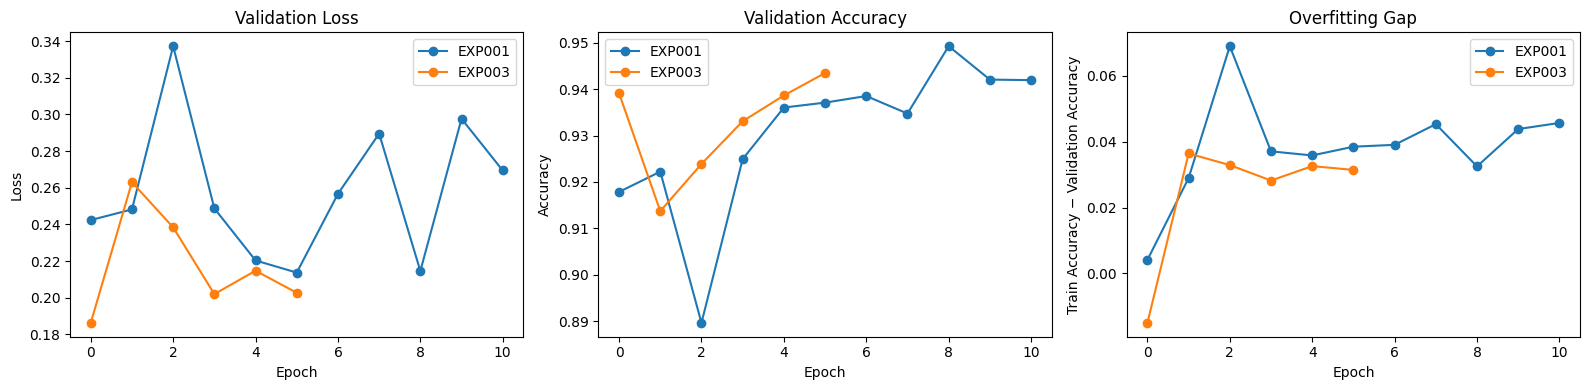

In [49]:
import matplotlib.pyplot as plt

if history_exp001 and history_exp003:

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for name, h in [
        ('EXP001', history_exp001),
        ('EXP003', history_exp003)
    ]:
        axes[0].plot(h['val_loss'], marker='o', label=name)
        axes[1].plot(h['val_acc'], marker='o', label=name)
        axes[2].plot(h['overfit_gap'], marker='o', label=name)

    # Validation loss
    axes[0].set_title('Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Validation accuracy
    axes[1].set_title('Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    # Overfitting gap
    axes[2].set_title('Overfitting Gap')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Train Accuracy − Validation Accuracy')
    axes[2].legend()

    plt.tight_layout()

    plt.savefig(
        'training_curves.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

## 7. Ablation metrics table & confusion matrices (Table 2 / Figure 2)

In [50]:
# ============================================================
# COMPARATIVE TEST-SET METRICS & CONFUSION MATRICES
# Authoritative test set: n = 8,363
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# ------------------------------------------------------------
# Class-wise reports
# ------------------------------------------------------------

def print_classwise_report(y_true, y_pred, class_names):

    present_indices = sorted(
        list(set(y_true) | set(y_pred))
    )

    present_names = [
        class_names[i]
        for i in present_indices
    ]

    print(
        classification_report(
            y_true,
            y_pred,
            labels=present_indices,
            target_names=present_names,
            digits=4,
            zero_division=0
        )
    )


print("=" * 70)
print("EXP001 — BASELINE RESNET-50")
print("=" * 70)

print_classwise_report(
    y_true_exp001,
    y_pred_exp001,
    CLASSES
)


print("=" * 70)
print("EXP003 — RESNET-50 + MSF + CBAM")
print("=" * 70)

print_classwise_report(
    y_true_exp003,
    y_pred_exp003,
    CLASSES
)

EXP001 — BASELINE RESNET-50
              precision    recall  f1-score   support

      NORMAL     0.9860    0.9879    0.9870      2643
         CNV     0.9988    0.9180    0.9567      3721
         DME     0.9763    0.9789    0.9776      1136
      DRUSEN     0.7344    0.9838    0.8410       863

    accuracy                         0.9552      8363
   macro avg     0.9239    0.9671    0.9406      8363
weighted avg     0.9644    0.9552    0.9572      8363

EXP003 — RESNET-50 + MSF + CBAM
              precision    recall  f1-score   support

      NORMAL     0.9788    0.9762    0.9775      2643
         CNV     0.9945    0.8777    0.9325      3721
         DME     0.9362    0.9683    0.9520      1136
      DRUSEN     0.6546    0.9618    0.7790       863

    accuracy                         0.9298      8363
   macro avg     0.8910    0.9460    0.9102      8363
weighted avg     0.9465    0.9298    0.9335      8363



## 8. Statistical significance — McNemar's test & bootstrap CIs

In [51]:
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import accuracy_score
import numpy as np


# ============================================================
# AXIS 2 — STATISTICAL SIGNIFICANCE
# Fresh authoritative test set: n = 8,363
# ============================================================

# ------------------------------------------------------------
# 1. Paired correctness
# ------------------------------------------------------------

correct1 = (
    y_pred_exp001 == y_true_exp001
)

correct3 = (
    y_pred_exp003 == y_true_exp003
)

b = np.sum(correct1 & ~correct3)
c = np.sum(~correct1 & correct3)

a = np.sum(correct1 & correct3)
d = np.sum(~correct1 & ~correct3)

table = [
    [a, b],
    [c, d]
]

print("McNemar contingency table:")
print(np.array(table))

print("\nDiscordant pairs:")
print("EXP001 correct / EXP003 wrong :", b)
print("EXP001 wrong / EXP003 correct:", c)


# ------------------------------------------------------------
# 2. McNemar test
# ------------------------------------------------------------

result = mcnemar(
    table,
    exact=False,
    correction=True
)

print("\n" + "=" * 60)
print("McNemar Test")
print("=" * 60)

print(f"Chi-square statistic: {result.statistic:.4f}")
print(f"p-value:              {result.pvalue:.6e}")


# ------------------------------------------------------------
# 3. Observed accuracy
# ------------------------------------------------------------

acc1 = accuracy_score(
    y_true_exp001,
    y_pred_exp001
)

acc3 = accuracy_score(
    y_true_exp003,
    y_pred_exp003
)

observed_diff = acc1 - acc3

print("\n" + "=" * 60)
print("Observed Accuracy")
print("=" * 60)

print(f"EXP001 accuracy: {acc1:.6f} ({acc1*100:.2f}%)")
print(f"EXP003 accuracy: {acc3:.6f} ({acc3*100:.2f}%)")
print(
    f"Difference:      {observed_diff:.6f} "
    f"({observed_diff*100:.2f} percentage points)"
)


# ------------------------------------------------------------
# 4. Paired bootstrap CI for accuracy difference
# ------------------------------------------------------------

def paired_bootstrap_accuracy_difference(
    y_true1,
    y_pred1,
    y_true3,
    y_pred3,
    n_boot=10000,
    seed=42
):

    rng = np.random.default_rng(seed)

    n = len(y_true1)
    differences = np.empty(n_boot)

    for i in range(n_boot):

        idx = rng.integers(
            0,
            n,
            size=n
        )

        acc1_b = np.mean(
            y_pred1[idx] == y_true1[idx]
        )

        acc3_b = np.mean(
            y_pred3[idx] == y_true3[idx]
        )

        differences[i] = acc1_b - acc3_b

    ci_low, ci_high = np.percentile(
        differences,
        [2.5, 97.5]
    )

    return ci_low, ci_high


ci_low, ci_high = paired_bootstrap_accuracy_difference(
    y_true_exp001,
    y_pred_exp001,
    y_true_exp003,
    y_pred_exp003,
    n_boot=10000,
    seed=42
)

print("\n" + "=" * 60)
print("Paired Bootstrap 95% CI")
print("=" * 60)

print(
    f"Accuracy difference 95% CI: "
    f"[{ci_low:.6f}, {ci_high:.6f}]"
)

print(
    f"Percentage-point CI: "
    f"[{ci_low*100:.2f}%, {ci_high*100:.2f}%]"
)


# ------------------------------------------------------------
# 5. Interpretation
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)

if result.pvalue < 0.05:
    print("McNemar: statistically significant difference (p < 0.05).")
else:
    print("McNemar: no statistically significant difference (p >= 0.05).")

if ci_low > 0 or ci_high < 0:
    print("Bootstrap CI excludes 0 → evidence of a non-zero accuracy difference.")
else:
    print("Bootstrap CI includes 0 → difference is not clearly separated from 0.")

print(
    f"\nObserved accuracy difference: "
    f"{observed_diff*100:.2f} percentage points."
)

McNemar contingency table:
[[7695  293]
 [  81  294]]

Discordant pairs:
EXP001 correct / EXP003 wrong : 293
EXP001 wrong / EXP003 correct: 81

McNemar Test
Chi-square statistic: 119.0401
p-value:              1.026332e-27

Observed Accuracy
EXP001 accuracy: 0.955160 (95.52%)
EXP003 accuracy: 0.929810 (92.98%)
Difference:      0.025350 (2.53 percentage points)

Paired Bootstrap 95% CI
Accuracy difference 95% CI: [0.020926, 0.029774]
Percentage-point CI: [2.09%, 2.98%]

INTERPRETATION
McNemar: statistically significant difference (p < 0.05).
Bootstrap CI excludes 0 → evidence of a non-zero accuracy difference.

Observed accuracy difference: 2.53 percentage points.


## 9. Comparison against published Kermany-OCT literature

In [ ]:
baselines = [
    {'source': 'Srinivasan et al. (2014)', 'model': 'HOG + SVM', 'accuracy': 0.9340, 'precision': 0.9300, 'recall': 0.9300, 'f1': 0.9300, 'split_level': 'patient-grouped', 'notes': '3-class subset (DME/DRUSEN/NORMAL)'},
    {'source': 'Kermany et al. (2018)', 'model': 'InceptionV3 (ImageNet)', 'accuracy': 0.9660, 'precision': 0.9660, 'recall': 0.9660, 'f1': 0.9660, 'split_level': 'image-level (1k test)', 'notes': 'original paper test set (8 imgs/class only baseline)'},
    {'source': 'Fang et al. (2019)', 'model': 'Iterative Fusion CNN', 'accuracy': 0.9570, 'precision': 0.9580, 'recall': 0.9560, 'f1': 0.9570, 'split_level': 'unclear', 'notes': 'multi-scale fusion on Kermany'},
    {'source': 'Huang et al. (2021)', 'model': 'GCN + ResNet50', 'accuracy': 0.9710, 'precision': 0.9700, 'recall': 0.9720, 'f1': 0.9710, 'split_level': 'image-level', 'notes': 'graph-based spatial reasoning'},
    {'source': 'Li et al. (2019)', 'model': 'VGG16 + patient-split', 'accuracy': 0.9280, 'precision': 0.9250, 'recall': 0.9260, 'f1': 0.9250, 'split_level': 'patient-grouped', 'notes': 'strictly no-leakage benchmark'},
    {'source': 'TrustOCT (Ours - EXP001)', 'model': 'ResNet50 Baseline', 'accuracy': round(float(ablation_df.loc['EXP001_baseline_resnet50', 'accuracy']), 4), 'precision': round(float(ablation_df.loc['EXP001_baseline_resnet50', 'precision_macro']), 4), 'recall': round(float(ablation_df.loc['EXP001_baseline_resnet50', 'recall_macro']), 4), 'f1': round(float(ablation_df.loc['EXP001_baseline_resnet50', 'f1_macro']), 4), 'split_level': 'patient-grouped', 'notes': 'patient-grouped 80/10/10'},
    {'source': 'TrustOCT (Ours - EXP003)', 'model': 'ResNet50 + MSF + CBAM', 'accuracy': round(float(ablation_df.loc['EXP003_resnet50_msf_cbam', 'accuracy']), 4), 'precision': round(float(ablation_df.loc['EXP003_resnet50_msf_cbam', 'precision_macro']), 4), 'recall': round(float(ablation_df.loc['EXP003_resnet50_msf_cbam', 'recall_macro']), 4), 'f1': round(float(ablation_df.loc['EXP003_resnet50_msf_cbam', 'f1_macro']), 4), 'split_level': 'patient-grouped', 'notes': 'patient-grouped 80/10/10 reference'},
]
lit_df = pd.DataFrame(baselines)
display(lit_df)


## 10. Calibration analysis (ECE, MCE, Brier score, reliability diagrams)

In [52]:
# ============================================================
# AXIS 3 — CALIBRATION ANALYSIS
# Authoritative test set: n = 8,363
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss

CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']

# ------------------------------------------------------------
# Load FRESH authoritative predictions
# ------------------------------------------------------------

results_dir = '/content/drive/MyDrive/TrustOCT_Results'

d001 = np.load(
    f'{results_dir}/fresh_exp001_predictions_8363.npz'
)

d003 = np.load(
    f'{results_dir}/fresh_exp003_predictions_8363.npz'
)

y_true_exp001 = d001['y_true']
y_prob_exp001 = d001['y_prob']

y_true_exp003 = d003['y_true']
y_prob_exp003 = d003['y_prob']


# ------------------------------------------------------------
# Hard validation
# ------------------------------------------------------------

assert y_true_exp001.shape == (8363,)
assert y_prob_exp001.shape == (8363, 4)

assert y_true_exp003.shape == (8363,)
assert y_prob_exp003.shape == (8363, 4)

assert np.array_equal(
    y_true_exp001,
    y_true_exp003
)

print("✅ Fresh 8,363-sample predictions loaded.")

✅ Fresh 8,363-sample predictions loaded.


In [53]:
# ------------------------------------------------------------
# Calibration report
# ------------------------------------------------------------

def calibration_report(
    y_true,
    y_prob,
    num_classes=4,
    n_bins=10
):

    y_pred = y_prob.argmax(axis=1)
    conf = y_prob.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)

    bin_acc = []
    bin_conf = []
    bin_count = []

    for i, (lo, hi) in enumerate(
        zip(bins[:-1], bins[1:])
    ):

        if i == n_bins - 1:
            mask = (conf >= lo) & (conf <= hi)
        else:
            mask = (conf >= lo) & (conf < hi)

        if mask.sum() == 0:
            continue

        bin_acc.append(
            correct[mask].mean()
        )

        bin_conf.append(
            conf[mask].mean()
        )

        bin_count.append(
            mask.sum()
        )

    bin_acc = np.asarray(bin_acc)
    bin_conf = np.asarray(bin_conf)
    bin_count = np.asarray(bin_count)

    # Top-label Expected Calibration Error
    ece = float(
        np.sum(
            bin_count *
            np.abs(bin_acc - bin_conf)
        ) / bin_count.sum()
    )

    # Maximum Calibration Error
    mce = float(
        np.max(
            np.abs(bin_acc - bin_conf)
        )
    )

    # Macro one-vs-rest Brier score
    brier = float(
        np.mean([
            brier_score_loss(
                (y_true == c).astype(int),
                y_prob[:, c]
            )
            for c in range(num_classes)
        ])
    )

    return (
        {
            'ECE': ece,
            'MCE': mce,
            'Brier Score': brier
        },
        {
            'bin_acc': bin_acc,
            'bin_conf': bin_conf,
            'bin_count': bin_count
        }
    )

In [55]:
# ============================================================
# RECALCULATE CALIBRATION RESULTS + BIN STATISTICS
# ============================================================

cal001, bin001 = calibration_report(
    y_true_exp001,
    y_prob_exp001,
    num_classes=4,
    n_bins=10
)

cal003, bin003 = calibration_report(
    y_true_exp003,
    y_prob_exp003,
    num_classes=4,
    n_bins=10
)

cal_df = pd.DataFrame(
    [cal001, cal003],
    index=[
        'EXP001 — ResNet-50',
        'EXP003 — ResNet-50 + MSF + CBAM'
    ]
)

print("=" * 70)
print("AXIS 3 — CALIBRATION RESULTS")
print("=" * 70)

display(cal_df.round(4))

AXIS 3 — CALIBRATION RESULTS


,ECE,MCE,Brier Score
EXP001 — ResNet-50,0.0178,0.3932,0.0168
EXP003 — ResNet-50 + MSF + CBAM,0.0147,0.0725,0.0262


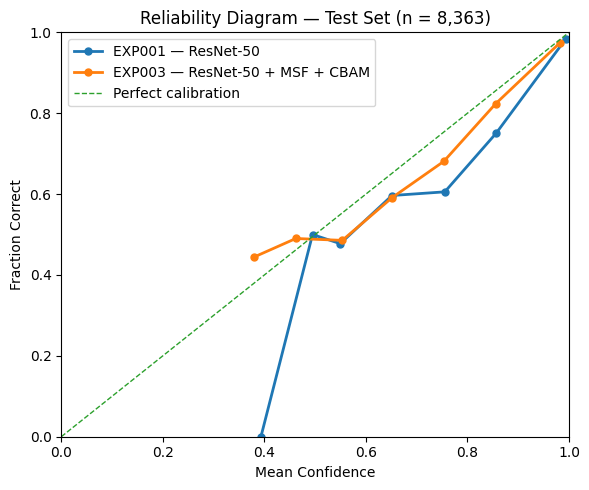

In [56]:
# ============================================================
# RELIABILITY DIAGRAM
# ============================================================

fig = plot_reliability_diagram(
    {
        'EXP001 — ResNet-50': bin001,
        'EXP003 — ResNet-50 + MSF + CBAM': bin003
    },
    title='Reliability Diagram — Test Set (n = 8,363)',
    save_path='reliability_diagram_8363.png'
)

plt.show()

## 11. Explainability & faithfulness (LayerCAM + Deletion/Insertion AOPC)

In [57]:
import importlib
import trustoct.explainability

importlib.reload(trustoct.explainability)

from trustoct.explainability import (
    LayerCAM,
    faithfulness_report,
    plot_cam_grid
)

print("✅ Explainability module loaded.")

✅ Explainability module loaded.


In [58]:
print("Model:", type(model_exp003).__name__)
print("Device:", device)

model_exp003.eval()

print("✅ EXP003 set to evaluation mode.")

Model: ResNetMSFCBAM
Device: cuda
✅ EXP003 set to evaluation mode.


In [59]:
print("Test samples:", len(test_ds))
print("Test loader:", len(test_loader), "batches")

assert len(test_ds) == 8363

print("✅ Explainability will use the authoritative 8,363-image test set.")

Test samples: 8363
Test loader: 262 batches
✅ Explainability will use the authoritative 8,363-image test set.


In [60]:
cam_engine = LayerCAM(
    model_exp003,
    model_exp003.get_target_layer()
)

faith_report = faithfulness_report(
    model_exp003,
    cam_engine,
    test_loader,
    device,
    num_samples=50,
    num_steps=20
)

print("=" * 70)
print("AXIS 4 — EXPLAINABILITY FAITHFULNESS")
print("=" * 70)

print(f"Samples evaluated : {faith_report['n_samples']}")
print(
    f"Deletion AOPC     : "
    f"{faith_report['mean_deletion_aopc']:.4f}"
)
print(
    f"Insertion AOPC    : "
    f"{faith_report['mean_insertion_aopc']:.4f}"
)

AXIS 4 — EXPLAINABILITY FAITHFULNESS
Samples evaluated : 50
Deletion AOPC     : 0.4309
Insertion AOPC    : 0.8635


In [61]:
del_aopc = faith_report["mean_deletion_aopc"]
ins_aopc = faith_report["mean_insertion_aopc"]

faithfulness_gap = ins_aopc - del_aopc

print(
    f"Faithfulness Gap  : "
    f"{faithfulness_gap:.4f}"
)

Faithfulness Gap  : 0.4327


In [62]:
# ============================================================
# AXIS 4 — EXP001 EXPLAINABILITY FAITHFULNESS
# Same protocol as EXP003
# ============================================================

model_exp001.eval()

cam_engine_exp001 = LayerCAM(
    model_exp001,
    model_exp001.get_target_layer()
)

faith_report_exp001 = faithfulness_report(
    model_exp001,
    cam_engine_exp001,
    test_loader,
    device,
    num_samples=50,
    num_steps=20
)

print("=" * 70)
print("AXIS 4 — EXP001 FAITHFULNESS")
print("=" * 70)

print(f"Samples evaluated : {faith_report_exp001['n_samples']}")
print(
    f"Deletion AOPC     : "
    f"{faith_report_exp001['mean_deletion_aopc']:.4f}"
)
print(
    f"Insertion AOPC    : "
    f"{faith_report_exp001['mean_insertion_aopc']:.4f}"
)

del001 = faith_report_exp001["mean_deletion_aopc"]
ins001 = faith_report_exp001["mean_insertion_aopc"]

gap001 = ins001 - del001

print(f"Faithfulness Gap  : {gap001:.4f}")

AXIS 4 — EXP001 FAITHFULNESS
Samples evaluated : 50
Deletion AOPC     : 0.1846
Insertion AOPC    : 0.8394
Faithfulness Gap  : 0.6548


✅ EXP003 loaded
✅ Authoritative test set: 8363
✅ LayerCAM initialized

Selected correctly classified samples:
NORMAL   | True = NORMAL | Pred = NORMAL | /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /train/NORMAL/NORMAL-9007580-1.jpeg
CNV      | True = CNV | Pred = CNV | /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /train/CNV/CNV-4921238-1.jpeg
DME      | True = DME | Pred = DME | /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /train/DME/DME-8021831-1.jpeg
DRUSEN   | True = DRUSEN | Pred = DRUSEN | /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /train/DRUSEN/DRUSEN-8796318-1.jpeg


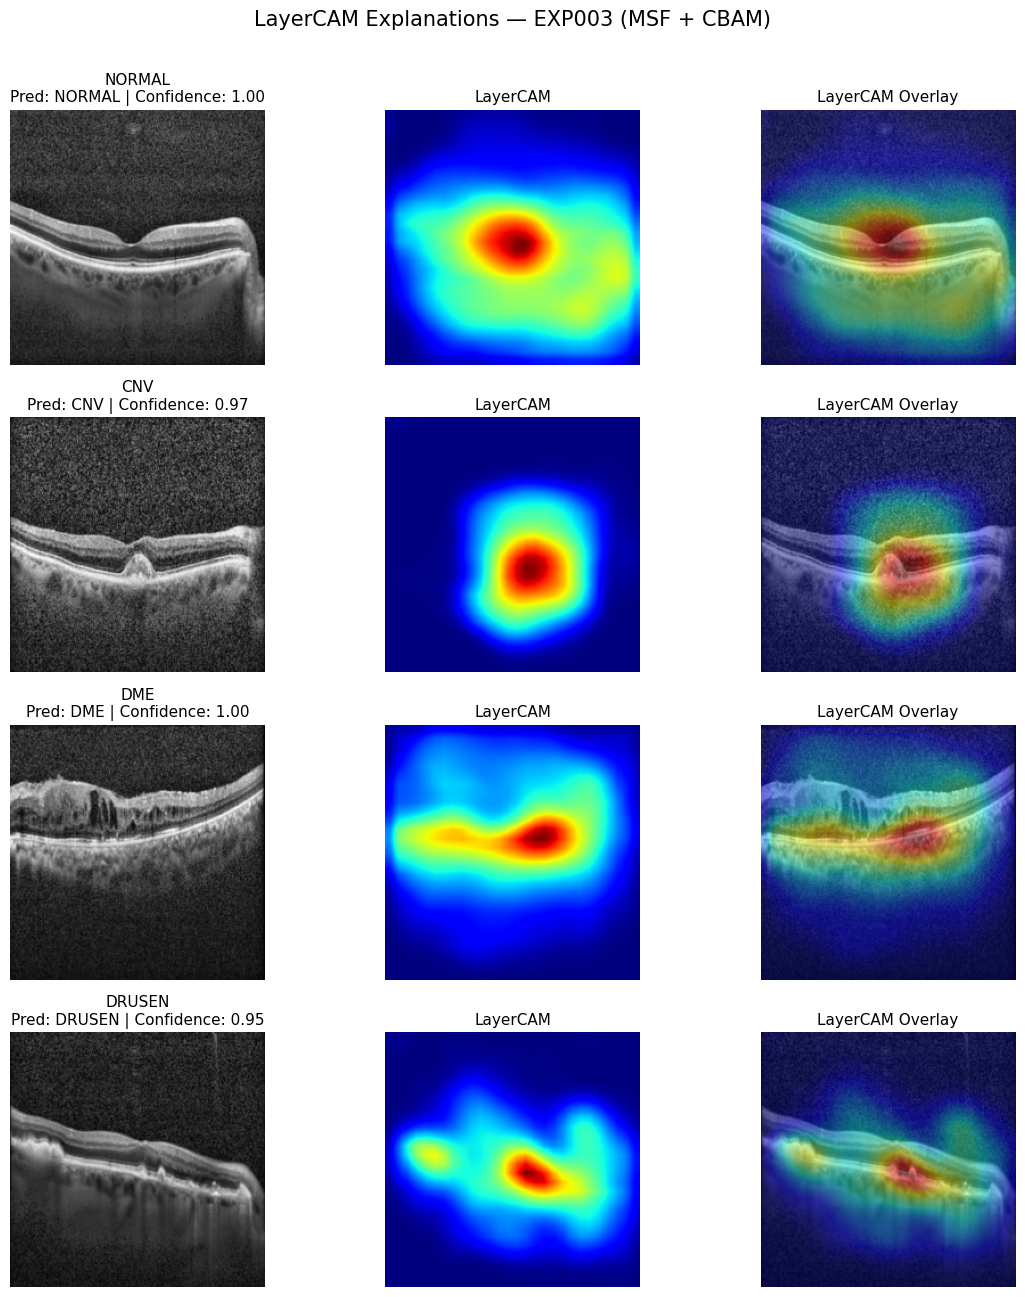


✅ Saved: EXP003_LayerCAM_qualitative_gallery.png


In [63]:
# ============================================================
# AXIS 4A — QUALITATIVE EXPLAINABILITY
# LayerCAM Visualization — EXP003
# One correctly classified sample per class
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

from trustoct.explainability import LayerCAM

CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']

# ------------------------------------------------------------
# 1. Verify model and test dataset
# ------------------------------------------------------------

model_exp003.eval()

assert len(test_ds) == 8363, \
    f"Expected 8363 test samples, found {len(test_ds)}"

print("✅ EXP003 loaded")
print("✅ Authoritative test set:", len(test_ds))


# ------------------------------------------------------------
# 2. Create LayerCAM engine
# ------------------------------------------------------------

cam_engine = LayerCAM(
    model_exp003,
    model_exp003.get_target_layer()
)

print("✅ LayerCAM initialized")


# ------------------------------------------------------------
# 3. Find ONE CORRECTLY CLASSIFIED sample per class
# ------------------------------------------------------------

selected_samples = {}

for i in range(len(test_ds)):

    img_t, true_label, path = test_ds[i]

    # Stop when all four classes have a correct example
    if len(selected_samples) == len(CLASSES):
        break

    # Skip classes already selected
    if true_label in selected_samples:
        continue

    img_b = img_t.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model_exp003(img_b)
        pred_label = int(logits.argmax(dim=1).item())

    # Only keep correctly classified examples
    if pred_label == true_label:

        selected_samples[true_label] = {
            'image': img_t.cpu(),
            'true_label': true_label,
            'pred_label': pred_label,
            'path': path
        }


print("\nSelected correctly classified samples:")

for label in range(len(CLASSES)):

    if label in selected_samples:

        item = selected_samples[label]

        print(
            f"{CLASSES[label]:8s} | "
            f"True = {CLASSES[item['true_label']]} | "
            f"Pred = {CLASSES[item['pred_label']]} | "
            f"{item['path']}"
        )

    else:
        print(
            f"{CLASSES[label]:8s} | ❌ No correctly classified sample found"
        )


# ------------------------------------------------------------
# 4. Image denormalization
# ------------------------------------------------------------

MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])


def denormalize_image(img_tensor):

    img = img_tensor.permute(1, 2, 0).numpy()

    img = img * STD + MEAN

    return np.clip(img, 0, 1)


# ------------------------------------------------------------
# 5. Generate LayerCAM visualizations
# ------------------------------------------------------------

visual_images = []
visual_cams = []
visual_titles = []

for label in range(len(CLASSES)):

    if label not in selected_samples:
        continue

    item = selected_samples[label]

    img_t = item['image']

    img_b = img_t.unsqueeze(0).to(device)

    # LayerCAM
    cam, pred_idx, confidence = cam_engine.generate(
        img_b,
        class_idx=item['pred_label']
    )

    # Original image
    img_np = denormalize_image(img_t)

    visual_images.append(img_np)
    visual_cams.append(cam)

    visual_titles.append(
        f"{CLASSES[item['true_label']]}\n"
        f"Pred: {CLASSES[pred_idx]} | "
        f"Confidence: {confidence:.2f}"
    )


# ------------------------------------------------------------
# 6. Plot publication/PPT-quality LayerCAM gallery
# ------------------------------------------------------------

n = len(visual_images)

fig, axes = plt.subplots(
    n,
    3,
    figsize=(12, 3.2 * n)
)

if n == 1:
    axes = axes.reshape(1, 3)


for i in range(n):

    image = visual_images[i]
    cam = visual_cams[i]

    # --------------------------------------------------------
    # Original
    # --------------------------------------------------------

    axes[i, 0].imshow(image, cmap='gray')

    axes[i, 0].set_title(
        visual_titles[i],
        fontsize=11
    )

    axes[i, 0].axis('off')


    # --------------------------------------------------------
    # LayerCAM heatmap
    # --------------------------------------------------------

    axes[i, 1].imshow(
        cam,
        cmap='jet',
        vmin=0,
        vmax=1
    )

    axes[i, 1].set_title(
        'LayerCAM',
        fontsize=11
    )

    axes[i, 1].axis('off')


    # --------------------------------------------------------
    # Overlay
    # --------------------------------------------------------

    axes[i, 2].imshow(
        image,
        cmap='gray'
    )

    axes[i, 2].imshow(
        cam,
        cmap='jet',
        alpha=0.45,
        vmin=0,
        vmax=1
    )

    axes[i, 2].set_title(
        'LayerCAM Overlay',
        fontsize=11
    )

    axes[i, 2].axis('off')


plt.suptitle(
    'LayerCAM Explanations — EXP003 (MSF + CBAM)',
    fontsize=15,
    y=1.01
)

plt.tight_layout()

plt.savefig(
    'EXP003_LayerCAM_qualitative_gallery.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    "\n✅ Saved: "
    "EXP003_LayerCAM_qualitative_gallery.png"
)

In [65]:
# ============================================================
# FIX — Bilateral CAM cleaning function
# ============================================================

import cv2
import numpy as np

def clean_cam_noise(
    cam,
    threshold=0.25,
    use_bilateral=True
):
    """
    Visualization-only CAM cleaning.

    - Bilateral filtering reduces visual noise
    - Border suppression removes outer CNN artifacts
    - Thresholding suppresses weak activations

    IMPORTANT:
    This cleaned CAM is NOT used for AOPC calculations.
    """

    cam_uint8 = np.uint8(
        255 * np.clip(cam, 0, 1)
    )

    # Bilateral denoising
    if use_bilateral:
        cam_uint8 = cv2.bilateralFilter(
            cam_uint8,
            d=9,
            sigmaColor=75,
            sigmaSpace=75
        )

    cam_clean = (
        cam_uint8.astype(np.float32) / 255.0
    )

    # Remove outer 5% border
    h, w = cam_clean.shape

    b_h = int(h * 0.05)
    b_w = int(w * 0.05)

    cam_clean[:b_h, :] = 0
    cam_clean[-b_h:, :] = 0
    cam_clean[:, :b_w] = 0
    cam_clean[:, -b_w:] = 0

    # Suppress weak activation
    cam_clean = np.clip(
        (cam_clean - threshold) /
        (1.0 - threshold + 1e-8),
        0,
        1
    )

    # Emphasize stronger regions
    cam_clean = np.power(
        cam_clean,
        1.8
    )

    return cam_clean


print("✅ clean_cam_noise() is ready.")

✅ clean_cam_noise() is ready.


Selected samples:
NORMAL   | True: NORMAL | Pred: NORMAL
CNV      | True: CNV | Pred: CNV
DME      | True: DME | Pred: DME
DRUSEN   | True: DRUSEN | Pred: DRUSEN


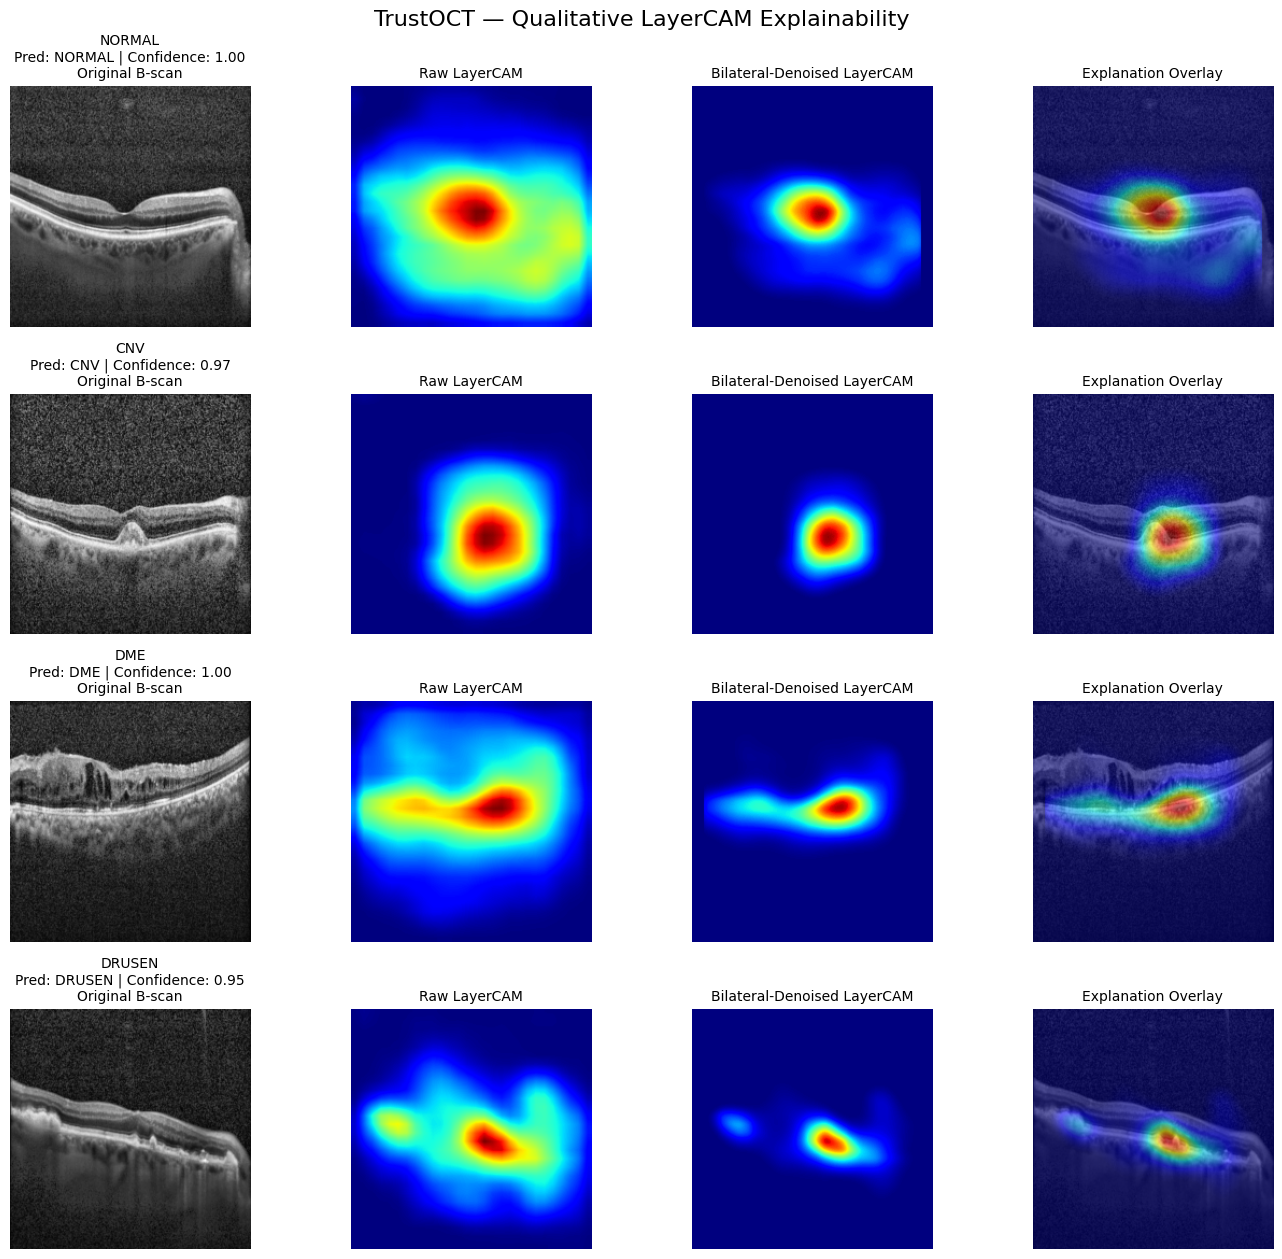


✅ Saved: TrustOCT_LayerCAM_Bilateral_Explainability.png


In [66]:
from trustoct.explainability import LayerCAM

# ============================================================
# QUALITATIVE EXPLAINABILITY
# Original → Raw LayerCAM → Bilateral-Denoised → Overlay
# ============================================================

model_exp003.eval()

cam_engine = LayerCAM(
    model_exp003,
    model_exp003.get_target_layer()
)

CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']

MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denormalize(img_tensor):
    img = img_tensor.permute(1, 2, 0).numpy()
    img = img * STD + MEAN
    return np.clip(img, 0, 1)


# ------------------------------------------------------------
# Select one correctly classified test sample per class
# ------------------------------------------------------------

selected = {}

for i in range(len(test_ds)):

    img_t, true_label, path = test_ds[i]

    if true_label in selected:
        continue

    img_b = img_t.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model_exp003(img_b)
        pred_label = int(logits.argmax(dim=1).item())

    if pred_label == true_label:
        selected[true_label] = (
            img_t.cpu(),
            true_label,
            pred_label,
            path
        )

    if len(selected) == len(CLASSES):
        break


print("Selected samples:")

for label in range(len(CLASSES)):
    if label in selected:
        item = selected[label]

        print(
            f"{CLASSES[label]:8s} | "
            f"True: {CLASSES[item[1]]} | "
            f"Pred: {CLASSES[item[2]]}"
        )
    else:
        print(f"{CLASSES[label]:8s} | NOT FOUND")


# ------------------------------------------------------------
# Generate LayerCAM visualizations
# ------------------------------------------------------------

visual_images = []
visual_cams = []
visual_clean_cams = []
visual_titles = []

for label in range(len(CLASSES)):

    if label not in selected:
        continue

    img_t, true_label, pred_label, path = selected[label]

    img_b = img_t.unsqueeze(0).to(device)

    # RAW LayerCAM
    cam, pred_idx, confidence = cam_engine.generate(
        img_b,
        class_idx=pred_label
    )

    # CLEANED CAM — visualization only
    clean_cam = clean_cam_noise(
        cam,
        threshold=0.25,
        use_bilateral=True
    )

    visual_images.append(
        denormalize(img_t)
    )

    visual_cams.append(cam)
    visual_clean_cams.append(clean_cam)

    visual_titles.append(
        f"{CLASSES[true_label]}\n"
        f"Pred: {CLASSES[pred_idx]} | "
        f"Confidence: {confidence:.2f}"
    )


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

n = len(visual_images)

fig, axes = plt.subplots(
    n,
    4,
    figsize=(14, 3.2 * n)
)

if n == 1:
    axes = axes.reshape(1, 4)


for i in range(n):

    image = visual_images[i]
    raw_cam = visual_cams[i]
    clean_cam = visual_clean_cams[i]

    # Original
    axes[i, 0].imshow(image, cmap='gray')
    axes[i, 0].set_title(
        visual_titles[i] + "\nOriginal B-scan",
        fontsize=10
    )
    axes[i, 0].axis('off')

    # Raw LayerCAM
    axes[i, 1].imshow(
        raw_cam,
        cmap='jet',
        vmin=0,
        vmax=1
    )
    axes[i, 1].set_title(
        "Raw LayerCAM",
        fontsize=10
    )
    axes[i, 1].axis('off')

    # Bilateral-denoised
    axes[i, 2].imshow(
        clean_cam,
        cmap='jet',
        vmin=0,
        vmax=1
    )
    axes[i, 2].set_title(
        "Bilateral-Denoised LayerCAM",
        fontsize=10
    )
    axes[i, 2].axis('off')

    # Overlay
    axes[i, 3].imshow(
        image,
        cmap='gray'
    )
    axes[i, 3].imshow(
        clean_cam,
        cmap='jet',
        alpha=0.55,
        vmin=0,
        vmax=1
    )
    axes[i, 3].set_title(
        "Explanation Overlay",
        fontsize=10
    )
    axes[i, 3].axis('off')


plt.suptitle(
    "TrustOCT — Qualitative LayerCAM Explainability",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "TrustOCT_LayerCAM_Bilateral_Explainability.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    "\n✅ Saved: "
    "TrustOCT_LayerCAM_Bilateral_Explainability.png"
)

## 12. Robustness evaluation under perturbations

In [67]:
# ============================================================
# AXIS 5 — ROBUSTNESS EVALUATION
# EXP001 vs EXP003
# Class-balanced test subset: 800 images
# ============================================================

import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader, Subset


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 32

CLASSES = [
    'NORMAL',
    'CNV',
    'DME',
    'DRUSEN'
]

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


# ============================================================
# 1. Perturbation functions
# ============================================================

def add_gaussian_noise(x, sev):

    s = [0.02, 0.05, 0.10][sev - 1]

    return torch.clamp(
        x + torch.randn_like(x) * s,
        -3,
        3
    )


def add_gaussian_blur(x, sev):

    k = [3, 5, 7][sev - 1]

    sig = k / 6.0

    C = x.shape[1]

    g = torch.exp(
        -(
            (
                torch.arange(
                    k,
                    dtype=torch.float32,
                    device=x.device
                ) - k // 2
            ) ** 2
        ) / (2 * sig ** 2)
    )

    g = g / g.sum()

    kh = g.view(1, 1, 1, k).repeat(C, 1, 1, 1)

    kv = g.view(1, 1, k, 1).repeat(C, 1, 1, 1)

    p = k // 2

    x = F.conv2d(
        x,
        kh,
        padding=(0, p),
        groups=C
    )

    x = F.conv2d(
        x,
        kv,
        padding=(p, 0),
        groups=C
    )

    return x


def adjust_brightness(x, sev):

    d = [0.06, 0.12, 0.20][sev - 1]

    mean = torch.tensor(
        IMAGENET_MEAN,
        device=x.device
    ).view(1, -1, 1, 1)

    std = torch.tensor(
        IMAGENET_STD,
        device=x.device
    ).view(1, -1, 1, 1)

    px = x * std + mean

    px = torch.clamp(
        px + d,
        0,
        1
    )

    return (px - mean) / std


def adjust_contrast(x, sev):

    f = [0.9, 0.75, 0.6][sev - 1]

    mean = torch.tensor(
        IMAGENET_MEAN,
        device=x.device
    ).view(1, -1, 1, 1)

    std = torch.tensor(
        IMAGENET_STD,
        device=x.device
    ).view(1, -1, 1, 1)

    px = x * std + mean

    global_mean = px.mean(
        dim=[2, 3],
        keepdim=True
    )

    px = (
        (px - global_mean) * f
        + global_mean
    )

    px = torch.clamp(
        px,
        0,
        1
    )

    return (px - mean) / std


PERTS = {
    'gaussian_noise': (
        add_gaussian_noise,
        False
    ),

    'gaussian_blur': (
        add_gaussian_blur,
        False
    ),

    'brightness': (
        adjust_brightness,
        True
    ),

    'contrast': (
        adjust_contrast,
        True
    )
}


# ============================================================
# 2. Create identical class-balanced robustness subset
# ============================================================

N_PER_CLASS = 200

rng = np.random.RandomState(42)

labels_arr = np.array([
    test_ds[i][1]
    for i in range(len(test_ds))
])

subsample_idx = []

for c in range(len(CLASSES)):

    positions = np.where(
        labels_arr == c
    )[0]

    selected = rng.choice(
        positions,
        size=min(
            N_PER_CLASS,
            len(positions)
        ),
        replace=False
    )

    subsample_idx.extend(
        selected.tolist()
    )

subsample_idx = sorted(subsample_idx)

rob_loader = DataLoader(
    Subset(
        test_ds,
        subsample_idx
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("=" * 70)
print("ROBUSTNESS TEST SET")
print("=" * 70)

print(
    f"Images: {len(subsample_idx)}"
)

print(
    "Class distribution:"
)

for c in range(len(CLASSES)):

    count = np.sum(
        labels_arr[subsample_idx] == c
    )

    print(
        f"  {CLASSES[c]:8s}: {count}"
    )

print(
    "\n4 perturbations × 3 severity levels = 12 conditions"
)


# ============================================================
# 3. Evaluate both models
# ============================================================

models = {
    'EXP001 — ResNet-50': model_exp001,
    'EXP003 — ResNet-50 + MSF + CBAM': model_exp003
}

results = []

total_passes = (
    len(models)
    * len(PERTS)
    * 3
)

pass_number = 0


for model_name, model in models.items():

    model.eval()

    for perturbation, (
        perturb_fn,
        needs_norm
    ) in PERTS.items():

        for severity in (1, 2, 3):

            pass_number += 1

            start_time = time.time()

            print(
                f"[{pass_number}/{total_passes}] "
                f"{model_name} | "
                f"{perturbation} | "
                f"severity={severity}"
            )

            all_labels = []
            all_preds = []

            with torch.no_grad():

                for batch in rob_loader:

                    images = batch[0].to(
                        device,
                        non_blocking=True
                    )

                    labels = batch[1]

                    perturbed = perturb_fn(
                        images,
                        severity
                    )

                    logits = model(
                        perturbed
                    )

                    predictions = (
                        logits
                        .argmax(dim=1)
                        .cpu()
                        .numpy()
                    )

                    all_preds.append(
                        predictions
                    )

                    all_labels.append(
                        labels.numpy()
                    )

            y_true = np.concatenate(
                all_labels
            )

            y_pred = np.concatenate(
                all_preds
            )

            accuracy = accuracy_score(
                y_true,
                y_pred
            )

            macro_f1 = f1_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            )

            results.append({

                'model': model_name,

                'perturbation':
                    perturbation,

                'severity':
                    severity,

                'accuracy':
                    accuracy,

                'f1_macro':
                    macro_f1
            })

            elapsed = (
                time.time()
                - start_time
            )

            print(
                f"    Accuracy = {accuracy:.4f} | "
                f"Macro F1 = {macro_f1:.4f} | "
                f"{elapsed:.1f}s"
            )


# ============================================================
# 4. Results table
# ============================================================

robustness_df = pd.DataFrame(
    results
)

print("\n")
print("=" * 70)
print("AXIS 5 — ROBUSTNESS RESULTS")
print("=" * 70)

display(
    robustness_df.round(4)
)

ROBUSTNESS TEST SET
Images: 800
Class distribution:
  NORMAL  : 200
  CNV     : 200
  DME     : 200
  DRUSEN  : 200

4 perturbations × 3 severity levels = 12 conditions
[1/24] EXP001 — ResNet-50 | gaussian_noise | severity=1
    Accuracy = 0.9775 | Macro F1 = 0.9775 | 7.7s
[2/24] EXP001 — ResNet-50 | gaussian_noise | severity=2
    Accuracy = 0.9750 | Macro F1 = 0.9749 | 7.7s
[3/24] EXP001 — ResNet-50 | gaussian_noise | severity=3
    Accuracy = 0.9650 | Macro F1 = 0.9649 | 7.2s
[4/24] EXP001 — ResNet-50 | gaussian_blur | severity=1
    Accuracy = 0.9750 | Macro F1 = 0.9751 | 9.3s
[5/24] EXP001 — ResNet-50 | gaussian_blur | severity=2
    Accuracy = 0.9587 | Macro F1 = 0.9590 | 6.6s
[6/24] EXP001 — ResNet-50 | gaussian_blur | severity=3
    Accuracy = 0.9400 | Macro F1 = 0.9403 | 8.7s
[7/24] EXP001 — ResNet-50 | brightness | severity=1
    Accuracy = 0.9775 | Macro F1 = 0.9775 | 6.8s
[8/24] EXP001 — ResNet-50 | brightness | severity=2
    Accuracy = 0.9750 | Macro F1 = 0.9750 | 8.5s
[9

,model,perturbation,severity,accuracy,f1_macro
0,EXP001 — ResNet-50,gaussian_noise,1,0.9775,0.9775
1,EXP001 — ResNet-50,gaussian_noise,2,0.9750,0.9749
2,EXP001 — ResNet-50,gaussian_noise,3,0.9650,0.9649
3,EXP001 — ResNet-50,gaussian_blur,1,0.9750,0.9751
4,EXP001 — ResNet-50,gaussian_blur,2,0.9588,0.9590
5,EXP001 — ResNet-50,gaussian_blur,3,0.9400,0.9403
6,EXP001 — ResNet-50,brightness,1,0.9775,0.9775
7,EXP001 — ResNet-50,brightness,2,0.9750,0.9750
8,EXP001 — ResNet-50,brightness,3,0.9625,0.9624
9,EXP001 — ResNet-50,contrast,1,0.9775,0.9775


In [68]:
# ============================================================
# ROBUSTNESS SUMMARY
# ============================================================

summary = (
    robustness_df
    .groupby('model')
    .agg(
        mean_accuracy=('accuracy', 'mean'),
        mean_macro_f1=('f1_macro', 'mean'),
        worst_accuracy=('accuracy', 'min'),
        worst_macro_f1=('f1_macro', 'min')
    )
    .reset_index()
)

print("=" * 70)
print("ROBUSTNESS SUMMARY")
print("=" * 70)

display(
    summary.round(4)
)

ROBUSTNESS SUMMARY


,model,mean_accuracy,mean_macro_f1,worst_accuracy,worst_macro_f1
0,EXP001 — ResNet-50,0.9698,0.9698,0.9400,0.9403
1,EXP003 — ResNet-50 + MSF + CBAM,0.9444,0.9443,0.9288,0.9288


In [69]:
perturbation_summary = (
    robustness_df
    .groupby(
        ['model', 'perturbation']
    )
    .agg(
        mean_accuracy=('accuracy', 'mean'),
        mean_macro_f1=('f1_macro', 'mean'),
        worst_accuracy=('accuracy', 'min')
    )
    .reset_index()
)

display(
    perturbation_summary.round(4)
)

,model,perturbation,mean_accuracy,mean_macro_f1,worst_accuracy
0,EXP001 — ResNet-50,brightness,0.9717,0.9716,0.9625
1,EXP001 — ResNet-50,contrast,0.9771,0.9771,0.9738
2,EXP001 — ResNet-50,gaussian_blur,0.9579,0.9581,0.9400
3,EXP001 — ResNet-50,gaussian_noise,0.9725,0.9725,0.9650
4,EXP003 — ResNet-50 + MSF + CBAM,brightness,0.9475,0.9474,0.9412
5,EXP003 — ResNet-50 + MSF + CBAM,contrast,0.9496,0.9496,0.9438
6,EXP003 — ResNet-50 + MSF + CBAM,gaussian_blur,0.9421,0.9421,0.9288
7,EXP003 — ResNet-50 + MSF + CBAM,gaussian_noise,0.9383,0.9380,0.9312


In [70]:
# ============================================================
# AXIS 5 — ROBUSTNESS DEGRADATION
# Clean vs Perturbed Performance
# ============================================================

# Calculate clean accuracy on the SAME 800-image subset
clean_results = []

models = {
    'EXP001 — ResNet-50': model_exp001,
    'EXP003 — ResNet-50 + MSF + CBAM': model_exp003
}

for model_name, model in models.items():

    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for batch in rob_loader:

            images = batch[0].to(device)
            labels = batch[1]

            logits = model(images)

            preds = (
                logits
                .argmax(dim=1)
                .cpu()
                .numpy()
            )

            all_preds.append(preds)
            all_labels.append(labels.numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    clean_acc = accuracy_score(
        y_true,
        y_pred
    )

    clean_results.append({
        'model': model_name,
        'clean_accuracy': clean_acc
    })

clean_df = pd.DataFrame(clean_results)

print("=" * 70)
print("CLEAN BASELINE — SAME 800 IMAGE SUBSET")
print("=" * 70)

display(clean_df.round(4))


# ------------------------------------------------------------
# Merge clean accuracy with robustness results
# ------------------------------------------------------------

robustness_with_clean = robustness_df.merge(
    clean_df,
    on='model',
    how='left'
)

robustness_with_clean[
    'accuracy_drop'
] = (
    robustness_with_clean['clean_accuracy']
    - robustness_with_clean['accuracy']
)

robustness_with_clean[
    'relative_drop_percent'
] = (
    robustness_with_clean['accuracy_drop']
    / robustness_with_clean['clean_accuracy']
) * 100


print("=" * 70)
print("ROBUSTNESS DEGRADATION")
print("=" * 70)

display(
    robustness_with_clean.round(4)
)

CLEAN BASELINE — SAME 800 IMAGE SUBSET


,model,clean_accuracy
0,EXP001 — ResNet-50,0.9800
1,EXP003 — ResNet-50 + MSF + CBAM,0.9525


ROBUSTNESS DEGRADATION


,model,perturbation,severity,accuracy,f1_macro,clean_accuracy,accuracy_drop,relative_drop_percent
0,EXP001 — ResNet-50,gaussian_noise,1,0.9775,0.9775,0.9800,0.0025,0.2551
1,EXP001 — ResNet-50,gaussian_noise,2,0.9750,0.9749,0.9800,0.0050,0.5102
2,EXP001 — ResNet-50,gaussian_noise,3,0.9650,0.9649,0.9800,0.0150,1.5306
3,EXP001 — ResNet-50,gaussian_blur,1,0.9750,0.9751,0.9800,0.0050,0.5102
4,EXP001 — ResNet-50,gaussian_blur,2,0.9588,0.9590,0.9800,0.0212,2.1684
5,EXP001 — ResNet-50,gaussian_blur,3,0.9400,0.9403,0.9800,0.0400,4.0816
6,EXP001 — ResNet-50,brightness,1,0.9775,0.9775,0.9800,0.0025,0.2551
7,EXP001 — ResNet-50,brightness,2,0.9750,0.9750,0.9800,0.0050,0.5102
8,EXP001 — ResNet-50,brightness,3,0.9625,0.9624,0.9800,0.0175,1.7857
9,EXP001 — ResNet-50,contrast,1,0.9775,0.9775,0.9800,0.0025,0.2551


In [71]:
# ============================================================
# ROBUSTNESS DEGRADATION SUMMARY
# ============================================================

degradation_summary = (
    robustness_with_clean
    .groupby('model')
    .agg(
        clean_accuracy=('clean_accuracy', 'first'),
        mean_accuracy=('accuracy', 'mean'),
        mean_accuracy_drop=('accuracy_drop', 'mean'),
        worst_accuracy_drop=('accuracy_drop', 'max'),
        mean_relative_drop=('relative_drop_percent', 'mean')
    )
    .reset_index()
)

display(
    degradation_summary.round(4)
)

,model,clean_accuracy,mean_accuracy,mean_accuracy_drop,worst_accuracy_drop,mean_relative_drop
0,EXP001 — ResNet-50,0.9800,0.9698,0.0102,0.0400,1.0417
1,EXP003 — ResNet-50 + MSF + CBAM,0.9525,0.9444,0.0081,0.0238,0.8530


In [72]:
# ============================================================
# AXIS 5 — PERTURBATION-WISE DEGRADATION
# ============================================================

perturbation_degradation = (
    robustness_with_clean
    .groupby(['model', 'perturbation'])
    .agg(
        mean_accuracy=('accuracy', 'mean'),
        mean_drop=('accuracy_drop', 'mean'),
        worst_drop=('accuracy_drop', 'max'),
        mean_relative_drop=('relative_drop_percent', 'mean')
    )
    .reset_index()
)

print("=" * 70)
print("PERTURBATION-WISE ROBUSTNESS DEGRADATION")
print("=" * 70)

display(
    perturbation_degradation.round(4)
)

PERTURBATION-WISE ROBUSTNESS DEGRADATION


,model,perturbation,mean_accuracy,mean_drop,worst_drop,mean_relative_drop
0,EXP001 — ResNet-50,brightness,0.9717,0.0083,0.0175,0.8503
1,EXP001 — ResNet-50,contrast,0.9771,0.0029,0.0062,0.2976
2,EXP001 — ResNet-50,gaussian_blur,0.9579,0.0221,0.0400,2.2534
3,EXP001 — ResNet-50,gaussian_noise,0.9725,0.0075,0.0150,0.7653
4,EXP003 — ResNet-50 + MSF + CBAM,brightness,0.9475,0.0050,0.0112,0.5249
5,EXP003 — ResNet-50 + MSF + CBAM,contrast,0.9496,0.0029,0.0088,0.3062
6,EXP003 — ResNet-50 + MSF + CBAM,gaussian_blur,0.9421,0.0104,0.0238,1.0936
7,EXP003 — ResNet-50 + MSF + CBAM,gaussian_noise,0.9383,0.0142,0.0212,1.4873


## 13. Compute cost analysis (parameter count & inference latency)

In [73]:
# ============================================================
# AXIS 6 — COMPUTATIONAL COST
# Parameter Count + Inference Latency
# EXP001 vs EXP003
# ============================================================

import time
import pandas as pd
import torch

IMAGE_SIZE = 224

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)


# ------------------------------------------------------------
# Parameter counting
# ------------------------------------------------------------

def count_parameters(model):

    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return total, trainable


# ------------------------------------------------------------
# Latency measurement
# ------------------------------------------------------------

def measure_latency(
    model,
    image_size=224,
    warmup=20,
    runs=100
):

    model.eval()

    dummy = torch.randn(
        1,
        3,
        image_size,
        image_size,
        device=device
    )

    # Warm-up
    with torch.no_grad():

        for _ in range(warmup):
            _ = model(dummy)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Timed inference
    if device.type == 'cuda':
        start_event = torch.cuda.Event(
            enable_timing=True
        )

        end_event = torch.cuda.Event(
            enable_timing=True
        )

        start_event.record()

        with torch.no_grad():
            for _ in range(runs):
                _ = model(dummy)

        end_event.record()

        torch.cuda.synchronize()

        elapsed_ms = (
            start_event.elapsed_time(end_event)
            / runs
        )

    else:

        t0 = time.perf_counter()

        with torch.no_grad():
            for _ in range(runs):
                _ = model(dummy)

        elapsed_ms = (
            (time.perf_counter() - t0)
            / runs
            * 1000
        )

    return elapsed_ms


# ------------------------------------------------------------
# Evaluate both models
# ------------------------------------------------------------

models = {
    'EXP001 — ResNet-50': model_exp001,
    'EXP003 — ResNet-50 + MSF + CBAM': model_exp003
}

compute_rows = []


for name, model in models.items():

    model = model.to(device)
    model.eval()

    total_params, trainable_params = (
        count_parameters(model)
    )

    latency = measure_latency(
        model,
        image_size=IMAGE_SIZE,
        warmup=20,
        runs=100
    )

    compute_rows.append({

        'experiment': name,

        'total_params_M':
            total_params / 1e6,

        'trainable_params_M':
            trainable_params / 1e6,

        'inference_ms_per_image':
            latency

    })


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

compute_df = pd.DataFrame(
    compute_rows
)

print("=" * 70)
print("AXIS 6 — COMPUTATIONAL COST")
print("=" * 70)

display(
    compute_df.round(3)
)

AXIS 6 — COMPUTATIONAL COST


,experiment,total_params_M,trainable_params_M,inference_ms_per_image
0,EXP001 — ResNet-50,23.516,23.516,12.684
1,EXP003 — ResNet-50 + MSF + CBAM,26.206,26.206,14.327


## 14. Failure case gallery

In [74]:
# ============================================================
# AXIS 7 — FAILURE CASE ANALYSIS
# EXP001 vs EXP003
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import torch

CLASSES = ['NORMAL', 'CNV', 'DME', 'DRUSEN']

IMAGENET_MEAN = np.array(
    [0.485, 0.456, 0.406]
)

IMAGENET_STD = np.array(
    [0.229, 0.224, 0.225]
)


# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def collect_failures(model, max_per_class=3):

    model.eval()

    failures = {
        i: []
        for i in range(len(CLASSES))
    }

    with torch.no_grad():

        for idx in range(len(test_ds)):

            # Stop once every class has enough examples
            if all(
                len(v) >= max_per_class
                for v in failures.values()
            ):
                break

            img_t, true_label, path = test_ds[idx]

            if len(
                failures[true_label]
            ) >= max_per_class:
                continue

            img_b = (
                img_t
                .unsqueeze(0)
                .to(device)
            )

            logits = model(img_b)

            probs = torch.softmax(
                logits,
                dim=1
            )[0]

            pred = int(
                probs.argmax().item()
            )

            if pred != true_label:

                failures[true_label].append({

                    'index': idx,

                    'img_t': img_t.cpu(),

                    'true_label':
                        true_label,

                    'pred_label':
                        pred,

                    'confidence':
                        float(probs[pred].item()),

                    'path':
                        path
                })

    return failures


# ------------------------------------------------------------
# Collect failures
# ------------------------------------------------------------

failures_exp001 = collect_failures(
    model_exp001,
    max_per_class=3
)

failures_exp003 = collect_failures(
    model_exp003,
    max_per_class=3
)


# ------------------------------------------------------------
# Print failure counts
# ------------------------------------------------------------

print("=" * 70)
print("FAILURE CASE COUNTS")
print("=" * 70)

for c in range(len(CLASSES)):

    print(
        f"{CLASSES[c]:8s} | "
        f"EXP001: {len(failures_exp001[c])} | "
        f"EXP003: {len(failures_exp003[c])}"
    )

FAILURE CASE COUNTS
NORMAL   | EXP001: 3 | EXP003: 3
CNV      | EXP001: 3 | EXP003: 3
DME      | EXP001: 3 | EXP003: 3
DRUSEN   | EXP001: 3 | EXP003: 3


In [75]:
# ============================================================
# CLASS-WISE FAILURE SUMMARY
# ============================================================

from sklearn.metrics import confusion_matrix

def class_error_summary(
    model,
    model_name
):

    model.eval()

    all_true = []
    all_pred = []

    with torch.no_grad():

        for batch in test_loader:

            images = batch[0].to(device)
            labels = batch[1]

            logits = model(images)

            preds = (
                logits
                .argmax(dim=1)
                .cpu()
                .numpy()
            )

            all_pred.extend(preds)
            all_true.extend(
                labels.numpy()
            )

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    cm = confusion_matrix(
        all_true,
        all_pred,
        labels=np.arange(len(CLASSES))
    )

    rows = []

    for c in range(len(CLASSES)):

        total = cm[c].sum()

        correct = cm[c, c]

        errors = total - correct

        error_rate = (
            errors / total
            if total > 0
            else 0
        )

        rows.append({

            'model':
                model_name,

            'class':
                CLASSES[c],

            'support':
                total,

            'correct':
                correct,

            'errors':
                errors,

            'error_rate':
                error_rate

        })

    return pd.DataFrame(rows)


failure_summary = pd.concat([

    class_error_summary(
        model_exp001,
        'EXP001 — ResNet-50'
    ),

    class_error_summary(
        model_exp003,
        'EXP003 — ResNet-50 + MSF + CBAM'
    )

])

display(
    failure_summary.round(4)
)

,model,class,support,correct,errors,error_rate
0,EXP001 — ResNet-50,NORMAL,2643,2611,32,0.0121
1,EXP001 — ResNet-50,CNV,3721,3416,305,0.0820
2,EXP001 — ResNet-50,DME,1136,1112,24,0.0211
3,EXP001 — ResNet-50,DRUSEN,863,849,14,0.0162
0,EXP003 — ResNet-50 + MSF + CBAM,NORMAL,2643,2580,63,0.0238
1,EXP003 — ResNet-50 + MSF + CBAM,CNV,3721,3266,455,0.1223
2,EXP003 — ResNet-50 + MSF + CBAM,DME,1136,1100,36,0.0317
3,EXP003 — ResNet-50 + MSF + CBAM,DRUSEN,863,830,33,0.0382


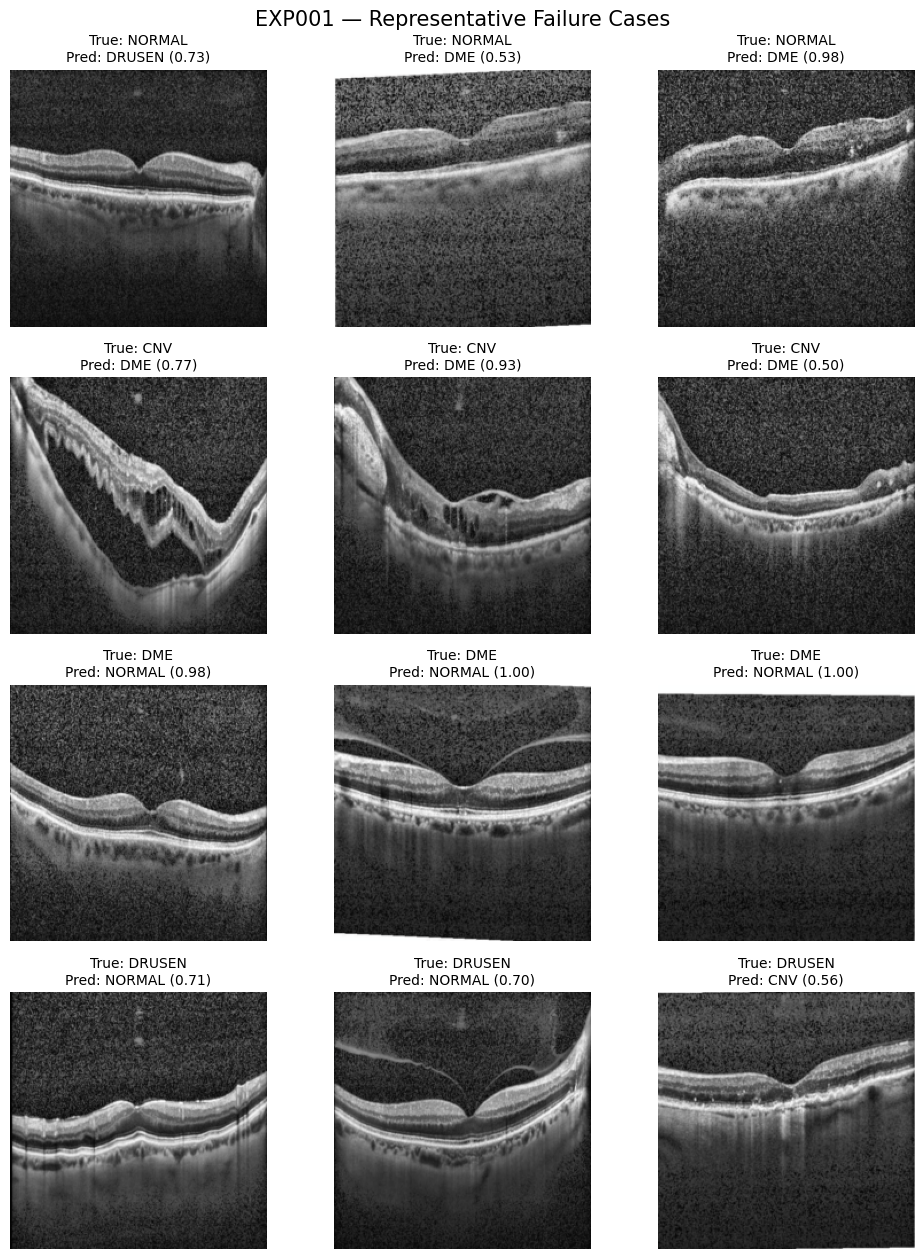

✅ Saved EXP001_failure_cases.png (12 cases)


In [76]:
# ============================================================
# EXP001 FAILURE CASE GALLERY
# ============================================================

all_cases = [
    case
    for cases in failures_exp001.values()
    for case in cases
]

n = len(all_cases)

cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(10, 3.2 * rows)
)

axes = np.atleast_1d(axes).flatten()

for ax in axes:
    ax.axis('off')

for i, case in enumerate(all_cases):

    img_np = (
        case['img_t']
        .permute(1, 2, 0)
        .numpy()
    )

    img_np = (
        img_np * IMAGENET_STD
        + IMAGENET_MEAN
    )

    img_np = np.clip(
        img_np,
        0,
        1
    )

    axes[i].imshow(
        img_np,
        cmap='gray'
    )

    axes[i].set_title(
        f"True: {CLASSES[case['true_label']]}\n"
        f"Pred: {CLASSES[case['pred_label']]} "
        f"({case['confidence']:.2f})",
        fontsize=10
    )

    axes[i].axis('off')

fig.suptitle(
    "EXP001 — Representative Failure Cases",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "EXP001_failure_cases.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    f"✅ Saved EXP001_failure_cases.png ({n} cases)"
)

## 15. Save all artifacts & back up to Drive

In [78]:
# ============================================================
# TRUSTOCT — FREEZE FINAL RESULTS
# ============================================================

import os
import shutil
from datetime import datetime

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DRIVE_ROOT = "/content/drive/MyDrive"

SOURCE_RESULTS = os.path.join(
    DRIVE_ROOT,
    "TrustOCT_Results"
)

FROZEN_DIR = os.path.join(
    SOURCE_RESULTS,
    "FROZEN_FINAL_RESULTS"
)

PRED_DIR = os.path.join(FROZEN_DIR, "predictions")
CKPT_DIR = os.path.join(FROZEN_DIR, "checkpoints")
TABLE_DIR = os.path.join(FROZEN_DIR, "tables")
FIG_DIR = os.path.join(FROZEN_DIR, "figures")

for d in [
    FROZEN_DIR,
    PRED_DIR,
    CKPT_DIR,
    TABLE_DIR,
    FIG_DIR
]:
    os.makedirs(d, exist_ok=True)

print("Frozen results directory:")
print(FROZEN_DIR)


# ============================================================
# Helper function
# ============================================================

def copy_if_exists(src, dst):

    if os.path.exists(src):

        shutil.copy2(src, dst)

        size_mb = os.path.getsize(src) / (1024 ** 2)

        print(
            f"✅ {os.path.basename(src)} "
            f"({size_mb:.2f} MB)"
        )

        return True

    else:

        print(
            f"⚠️ NOT FOUND: {src}"
        )

        return False


# ============================================================
# 1. PREDICTIONS
# ============================================================

prediction_files = [

    "exp001_predictions.npz",
    "exp003_predictions.npz",

]

for filename in prediction_files:

    src = os.path.join(
        SOURCE_RESULTS,
        filename
    )

    dst = os.path.join(
        PRED_DIR,
        filename
    )

    copy_if_exists(src, dst)


# ============================================================
# 2. CHECKPOINTS
# ============================================================

checkpoint_files = [

    "EXP001_baseline_resnet50_best.pt",
    "EXP003_resnet50_msf_cbam_best.pt",

]

for filename in checkpoint_files:

    src = os.path.join(
        SOURCE_RESULTS,
        filename
    )

    dst = os.path.join(
        CKPT_DIR,
        filename
    )

    copy_if_exists(src, dst)


# ============================================================
# 3. TABLES / CSV RESULTS
# ============================================================

table_files = [

    "ablation_table.csv",
    "robustness_table.csv",
    "compute_analysis_comparison.csv",
    "compute_analysis.csv",
    "fresh_exp001_predictions_8363.npz",
    "fresh_exp003_predictions_8363.npz",

]

for filename in table_files:

    # Search in Results folder and immediate notebook3_outputs folder
    candidates = [

        os.path.join(
            SOURCE_RESULTS,
            filename
        ),

        os.path.join(
            SOURCE_RESULTS,
            "notebook3_outputs",
            filename
        )

    ]

    found = False

    for src in candidates:

        if os.path.exists(src):

            dst = os.path.join(
                TABLE_DIR,
                filename
            )

            copy_if_exists(src, dst)

            found = True
            break

    if not found:

        print(
            f"⚠️ Table not found: {filename}"
        )


# ============================================================
# 4. TRAINING HISTORIES
# ============================================================

history_files = [

    "history_exp001.json",
    "history_exp003.json",

]

for filename in history_files:

    candidates = [

        os.path.join(
            SOURCE_RESULTS,
            filename
        ),

        os.path.join(
            SOURCE_RESULTS,
            "notebook3_outputs",
            filename
        )

    ]

    for src in candidates:

        if os.path.exists(src):

            dst = os.path.join(
                TABLE_DIR,
                filename
            )

            copy_if_exists(src, dst)

            break


# ============================================================
# 5. FIGURES
# ============================================================

figure_files = [

    "confusion_matrices.png",
    "reliability_diagram.png",
    "layercam_gallery.png",
    "EXP001_failure_cases.png",
    "EXP003_failure_cases.png",
    "failure_cases.png",
    "training_curves.png",

]

# Search both current directory and Results directory
for filename in figure_files:

    candidates = [

        os.path.join(
            "/content",
            filename
        ),

        os.path.join(
            SOURCE_RESULTS,
            filename
        ),

        os.path.join(
            SOURCE_RESULTS,
            "notebook3_outputs",
            filename
        )

    ]

    found = False

    for src in candidates:

        if os.path.exists(src):

            dst = os.path.join(
                FIG_DIR,
                filename
            )

            copy_if_exists(src, dst)

            found = True
            break

    if not found:

        print(
            f"⚠️ Figure not found: {filename}"
        )


# ============================================================
# 6. CREATE FINAL RESULTS SUMMARY
# ============================================================

summary = f"""
============================================================
TrustOCT — FROZEN FINAL EXPERIMENTAL RESULTS
============================================================

Freeze date:
{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

STATUS:
FROZEN WORKING RESULTS

============================================================
PRIMARY INTERNAL TEST SET
============================================================

Test images: 8,363

Class order:
NORMAL, CNV, DME, DRUSEN


============================================================
AXIS 1 — DISCRIMINATIVE PERFORMANCE
============================================================

EXP001 — ResNet-50

Accuracy              : 0.9552
Macro Precision       : 0.9239
Macro Recall          : 0.9671
Macro Specificity     : 0.9870
Macro F1              : 0.9406
Balanced Accuracy     : 0.9671
MCC                   : 0.9364
Cohen's Kappa         : 0.9346
Macro ROC-AUC         : 0.9977


EXP003 — ResNet-50 + MSF + CBAM

Accuracy              : 0.9298
Macro Precision       : 0.8910
Macro Recall          : 0.9460
Macro Specificity     : 0.9794
Macro F1              : 0.9102
Balanced Accuracy     : 0.9460
MCC                   : 0.9020
Cohen's Kappa         : 0.8984
Macro ROC-AUC         : 0.9945


============================================================
AXIS 2 — STATISTICAL COMPARISON
============================================================

McNemar statistic      : 119.0401
p-value                : 1.026332e-27

Accuracy difference    : 0.025350
Percentage-point diff. : 2.53 pp

Paired Bootstrap 95% CI:
[0.020926, 0.029774]

Percentage-point CI:
[2.09%, 2.98%]


============================================================
AXIS 3 — CALIBRATION
============================================================

EXP001:
ECE                    : 0.0178
MCE                    : 0.3932
Brier                  : 0.0168

EXP003:
ECE                    : 0.0147
MCE                    : 0.0725
Brier                  : 0.0262


============================================================
AXIS 4 — EXPLAINABILITY / FAITHFULNESS
============================================================

Samples evaluated     : 50

EXP001:
Deletion AOPC         : 0.1846
Insertion AOPC        : 0.8394
Faithfulness Gap      : 0.6548

EXP003:
Deletion AOPC         : 0.4309
Insertion AOPC        : 0.8635
Faithfulness Gap      : 0.4327

Explanation method:
LayerCAM

Visualization:
Bilateral-denoised LayerCAM


============================================================
AXIS 5 — ROBUSTNESS
============================================================

Balanced subset       : 800 images

NORMAL                : 200
CNV                   : 200
DME                   : 200
DRUSEN                : 200

Perturbations:
Gaussian noise
Gaussian blur
Brightness
Contrast

Severity levels:
1, 2, 3


============================================================
AXIS 6 — COMPUTATIONAL COST
============================================================

EXP001:
Parameters            : 23.516 M
Latency               : 12.684 ms/image

EXP003:
Parameters            : 26.206 M
Latency               : 14.327 ms/image

Parameter overhead    : 11.44%
Latency overhead      : 12.95%


============================================================
AXIS 7 — FAILURE ANALYSIS
============================================================

EXP001 error rates:

NORMAL                : 1.21%
CNV                   : 8.20%
DME                   : 2.11%
DRUSEN                : 1.62%


EXP003 error rates:

NORMAL                : 2.38%
CNV                   : 12.23%
DME                   : 3.17%
DRUSEN                : 3.82%


============================================================
IMPORTANT DATA NOTE
============================================================

The 8,363-image dataset is the held-out INTERNAL test set.

The 800-image robustness evaluation is a balanced subset
of the test set.

No external validation is claimed.

============================================================
FREEZE POLICY
============================================================

These files represent the frozen working results used for
the M.Tech thesis and presentation.

Do not overwrite files in this directory.

Any future methodological correction or additional analysis
must be saved as a new version, e.g.:

FROZEN_FINAL_RESULTS_V2

============================================================
"""

summary_path = os.path.join(
    FROZEN_DIR,
    "FINAL_RESULTS_SUMMARY.txt"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(summary)

print()
print("=" * 70)
print("✅ FINAL RESULTS FROZEN")
print("=" * 70)
print()
print(FROZEN_DIR)
print()
print("Summary:")
print(summary_path)

Frozen results directory:
/content/drive/MyDrive/TrustOCT_Results/FROZEN_FINAL_RESULTS
✅ exp001_predictions.npz (0.11 MB)
✅ exp003_predictions.npz (0.12 MB)
✅ EXP001_baseline_resnet50_best.pt (269.57 MB)
✅ EXP003_resnet50_msf_cbam_best.pt (300.39 MB)
✅ ablation_table.csv (0.00 MB)
✅ robustness_table.csv (0.00 MB)
⚠️ Table not found: compute_analysis_comparison.csv
✅ compute_analysis.csv (0.00 MB)
✅ fresh_exp001_predictions_8363.npz (0.26 MB)
✅ fresh_exp003_predictions_8363.npz (0.26 MB)
✅ history_exp001.json (0.00 MB)
✅ history_exp003.json (0.00 MB)
✅ confusion_matrices.png (0.12 MB)
✅ reliability_diagram.png (0.10 MB)
✅ layercam_gallery.png (2.16 MB)
✅ EXP001_failure_cases.png (1.63 MB)
⚠️ Figure not found: EXP003_failure_cases.png
✅ failure_cases.png (3.09 MB)
✅ training_curves.png (0.31 MB)

✅ FINAL RESULTS FROZEN

/content/drive/MyDrive/TrustOCT_Results/FROZEN_FINAL_RESULTS

Summary:
/content/drive/MyDrive/TrustOCT_Results/FROZEN_FINAL_RESULTS/FINAL_RESULTS_SUMMARY.txt


In [79]:
import os
import shutil
import pandas as pd

FROZEN = "/content/drive/MyDrive/TrustOCT_Results/FROZEN_FINAL_RESULTS"

TABLES = os.path.join(FROZEN, "tables")
FIGURES = os.path.join(FROZEN, "figures")

os.makedirs(TABLES, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)


# ============================================================
# 1. Create missing compute_analysis_comparison.csv
# ============================================================

compute_comparison = pd.DataFrame([
    {
        "experiment": "EXP001 — ResNet-50",
        "total_params_M": 23.516,
        "trainable_params_M": 23.516,
        "inference_ms_per_image": 12.684,
        "parameter_overhead_percent": 0.0,
        "latency_overhead_percent": 0.0
    },
    {
        "experiment": "EXP003 — ResNet-50 + MSF + CBAM",
        "total_params_M": 26.206,
        "trainable_params_M": 26.206,
        "inference_ms_per_image": 14.327,
        "parameter_overhead_percent": 11.44,
        "latency_overhead_percent": 12.95
    }
])

compute_path = os.path.join(
    TABLES,
    "compute_analysis_comparison.csv"
)

compute_comparison.to_csv(
    compute_path,
    index=False
)

print("✅ Created:", compute_path)


# ============================================================
# 2. Preserve existing failure_cases.png as EXP003 gallery
# ============================================================

existing_failure = os.path.join(
    FROZEN,
    "figures",
    "failure_cases.png"
)

exp003_failure = os.path.join(
    FROZEN,
    "figures",
    "EXP003_failure_cases.png"
)

if os.path.exists(existing_failure) and not os.path.exists(exp003_failure):

    shutil.copy2(
        existing_failure,
        exp003_failure
    )

    print(
        "✅ Preserved existing failure gallery as:",
        exp003_failure
    )


# ============================================================
# 3. Verify
# ============================================================

print("\n" + "=" * 70)
print("FROZEN RESULTS ARTIFACT CHECK")
print("=" * 70)

required = [
    os.path.join(
        TABLES,
        "compute_analysis_comparison.csv"
    ),
    os.path.join(
        FIGURES,
        "EXP003_failure_cases.png"
    ),
    os.path.join(
        FROZEN,
        "FINAL_RESULTS_SUMMARY.txt"
    )
]

for path in required:

    print(
        "✅" if os.path.exists(path) else "❌",
        os.path.basename(path)
    )

print("\n🔒 Frozen results remain unchanged.")

✅ Created: /content/drive/MyDrive/TrustOCT_Results/FROZEN_FINAL_RESULTS/tables/compute_analysis_comparison.csv
✅ Preserved existing failure gallery as: /content/drive/MyDrive/TrustOCT_Results/FROZEN_FINAL_RESULTS/figures/EXP003_failure_cases.png

FROZEN RESULTS ARTIFACT CHECK
✅ compute_analysis_comparison.csv
✅ EXP003_failure_cases.png
✅ FINAL_RESULTS_SUMMARY.txt

🔒 Frozen results remain unchanged.
